In [466]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: '%.2f' % x)


print("All libraries imported successfully")

All libraries imported successfully


# Data Reading and Cleaning

In [390]:
df = pd.read_csv('/Users/keshav/Downloads/City Performance Data - Delivery Performance.csv')

df['date'] = pd.to_datetime(df['date'])

print(f"Shape:{df.shape[0]} rows × {df.shape[1]} columns")
print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Cities: {df['city'].unique()}")

Shape:1461 rows × 17 columns
Date range: 2022-01-01 -> 2025-12-31
Cities: ['Munich']


In [391]:
print("FIRST 5 ROWS")
display(df.head())

print("\nDATA TYPES")
print(df.dtypes)

print("\nBASIC STATISTICS")
display(df.describe())

FIRST 5 ROWS


,date,city,orders_delivered,potential,active_restaurants,daily_online_restaurants,daily_opening_hours,delivery_area_km2,order_distance_km,order_assign_to_restaurant_distance_km,order_restaurant_to_customer_distance_km,order_handling_time_mins,assign_time_mins,total_time_mins,working_hours,delivery_rating,delivery_time_target
0,2022-01-01,Munich,4518,5167,550,597,13.50,155.30,3.18,0.86,2.32,17.70,5.00,22.70,1979.20,3.60,30
1,2022-01-02,Munich,3835,4285,524,595,13.50,154.90,3.21,1.09,2.12,17.60,5.00,22.50,1780.70,3.70,30
2,2022-01-03,Munich,3261,3906,540,599,11.50,155.00,3.52,0.93,2.59,20.00,5.70,25.70,1603.40,3.30,30
3,2022-01-04,Munich,3279,4025,557,600,11.50,154.70,3.15,1.16,1.99,17.30,4.90,22.20,1498.40,3.70,30
4,2022-01-05,Munich,3322,4118,563,601,11.50,154.20,3.42,1.17,2.25,18.90,5.30,24.20,1496.50,3.60,30



DATA TYPES
date                                        datetime64[ns]
city                                                object
orders_delivered                                     int64
potential                                            int64
active_restaurants                                   int64
daily_online_restaurants                             int64
daily_opening_hours                                float64
delivery_area_km2                                  float64
order_distance_km                                  float64
order_assign_to_restaurant_distance_km             float64
order_restaurant_to_customer_distance_km           float64
order_handling_time_mins                           float64
assign_time_mins                                   float64
total_time_mins                                    float64
working_hours                                      float64
delivery_rating                                    float64
delivery_time_target                        

,date,orders_delivered,potential,active_restaurants,daily_online_restaurants,daily_opening_hours,delivery_area_km2,order_distance_km,order_assign_to_restaurant_distance_km,order_restaurant_to_customer_distance_km,order_handling_time_mins,assign_time_mins,total_time_mins,working_hours,delivery_rating,delivery_time_target
count,1461,1461.00,1461.00,1461.00,1461.00,1461.00,1461.00,1461.00,1461.00,1461.00,1461.00,1461.00,1461.00,1461.00,1458.00,1461.00
mean,2024-01-01 00:00:00,4971.61,5638.18,717.51,787.74,12.36,190.05,3.72,1.01,2.74,19.27,5.44,45.19,2238.69,3.54,30.00
min,2022-01-01 00:00:00,2965.00,3405.00,524.00,0.00,11.50,154.00,-9.90,0.60,1.80,16.50,4.60,21.10,1289.90,2.90,30.00
25%,2023-01-01 00:00:00,3933.00,4715.00,649.00,718.00,11.50,174.60,3.36,0.86,2.39,18.30,5.10,23.40,1853.40,3.40,30.00
50%,2024-01-01 00:00:00,4757.00,5571.00,680.00,736.00,11.50,175.80,3.76,1.01,2.75,19.30,5.40,24.70,2212.30,3.50,30.00
75%,2024-12-31 00:00:00,5604.00,6453.00,820.00,904.00,13.50,214.90,4.14,1.16,3.10,20.20,5.70,25.90,2574.10,3.60,30.00
max,2025-12-31 00:00:00,88888.00,9342.00,865.00,926.00,13.50,216.60,4.97,1.38,3.62,25.50,7.20,9999.00,3792.10,3.90,30.00
std,NaN,3920.10,1108.31,102.71,115.46,0.99,23.05,0.80,0.19,0.44,1.32,0.37,451.67,443.67,0.13,0.00


In [392]:
print("MISSING VALUES")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})[missing > 0]

MISSING VALUES


,Missing Count,Missing %
delivery_rating,3,0.21


In [393]:
df[df['delivery_rating'].isnull()][['date', 'delivery_rating', 'orders_delivered']].reset_index(drop=True)

,date,delivery_rating,orders_delivered
0,2023-01-03,NaN,3742
1,2023-08-25,NaN,4719
2,2025-01-06,NaN,6875


In [394]:
print("DUPLICATE ROWS")
df.duplicated().sum()

DUPLICATE ROWS


0

In [395]:
print("NEGATIVE OR ZERO VALUES CHECK")
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    n_zero_or_neg = (df[col] <= 0).sum()
    if n_zero_or_neg > 0:
        print(f"{col}: {n_zero_or_neg} zero/negative values")

NEGATIVE OR ZERO VALUES CHECK
daily_online_restaurants: 2 zero/negative values
order_distance_km: 3 zero/negative values


In [396]:
# 88,888 shows up as max in describe() - checking on what days this affects
df[df['orders_delivered'] > 20000][['date', 'orders_delivered', 'potential', 'working_hours']].reset_index(drop=True)

,date,orders_delivered,potential,working_hours
0,2022-10-22,88888,5515,2063.80
1,2024-10-15,88888,5559,2349.30
2,2025-07-09,88888,5808,2153.80


In [397]:
# 9,999 is clearly a sentinel - confirming which rows and checking sub-components
df[df['total_time_mins'] > 100][['date', 'total_time_mins','assign_time_mins', 'order_handling_time_mins']].reset_index(drop=True)

,date,total_time_mins,assign_time_mins,order_handling_time_mins
0,2024-04-20,9999.00,5.80,20.60
1,2024-10-07,9999.00,5.10,18.20
2,2025-04-02,9999.00,5.50,19.40


In [398]:
# Negative distance - checking if sub-distances are also corrupted or recoverable
df[df['order_distance_km'] <= 0][['date', 'order_distance_km','order_assign_to_restaurant_distance_km','order_restaurant_to_customer_distance_km']].reset_index(drop=True)

,date,order_distance_km,order_assign_to_restaurant_distance_km,order_restaurant_to_customer_distance_km
0,2023-02-12,-9.90,1.26,2.14
1,2023-08-14,-9.90,0.99,3.34
2,2023-11-14,-9.90,1.12,1.99


In [399]:
# Zero restaurants but orders still delivered — recording error, not operational
df[df['daily_online_restaurants'] == 0][['date', 'daily_online_restaurants','active_restaurants', 'orders_delivered']].reset_index(drop=True)

,date,daily_online_restaurants,active_restaurants,orders_delivered
0,2022-05-05,0,542,3619
1,2024-06-26,0,839,4809


In [400]:
print(f"orders_delivered > 20,000  : {len(df[df['orders_delivered'] > 20000])} rows")
print(f"total_time_mins > 100      : {len(df[df['total_time_mins'] > 100])} rows")
print(f"order_distance_km <= 0     : {len(df[df['order_distance_km'] <= 0])} rows")
print(f"daily_online_restaurants=0 : {len(df[df['daily_online_restaurants'] == 0])} rows")

orders_delivered > 20,000  : 3 rows
total_time_mins > 100      : 3 rows
order_distance_km <= 0     : 3 rows
daily_online_restaurants=0 : 2 rows


In [401]:
df_clean = df.copy()

# Remove dummy rows - 88,888 is physically impossible for Munich
# potential on same days confirms these are system placeholders
rows_before = len(df_clean)
df_clean = df_clean[df_clean['orders_delivered'] != 88888]
print(f"Removed {rows_before - len(df_clean)} rows (orders_delivered = 88,888)")

# Recalculate total_time where sentinel 9,999 was recorded
# Formula verified: total = assign_time + handling_time holds across all clean rows
mask_time = df_clean['total_time_mins'] == 9999
df_clean.loc[mask_time, 'total_time_mins'] = (df_clean.loc[mask_time, 'assign_time_mins'] +df_clean.loc[mask_time, 'order_handling_time_mins'])
print(f"Recalculated total_time_mins for {mask_time.sum()} rows")

# Reconstruct distance from sub-components : assign + restaurant-to-customer

mask_dist = df_clean['order_distance_km'] < 0
df_clean.loc[mask_dist, 'order_distance_km'] = (df_clean.loc[mask_dist, 'order_assign_to_restaurant_distance_km'] + df_clean.loc[mask_dist, 'order_restaurant_to_customer_distance_km'])
print(f"Recalculated order_distance_km for {mask_dist.sum()} rows")

# Zero restaurants on days with active orders = recording error, not closure
# Forward fill from prior day is safe — restaurant availability is stable day-to-day (also both days are week days)
df_clean['daily_online_restaurants'] = (df_clean['daily_online_restaurants'].replace(0, np.nan).ffill())

# Linear interpolation for 3 missing rating values
df_clean['delivery_rating'] = df_clean['delivery_rating'].interpolate(method='linear')

print(f"\nOriginal rows : {len(df)}")
print(f"Clean rows    : {len(df_clean)}")
print(f"Rows removed  : {len(df) - len(df_clean)}")

Removed 3 rows (orders_delivered = 88,888)
Recalculated total_time_mins for 3 rows
Recalculated order_distance_km for 3 rows

Original rows : 1461
Clean rows    : 1458
Rows removed  : 3


In [402]:
# Verify if fixes applied correctly

# total_time_mins should no longer contain 9999
prev_bad_time = df[df['total_time_mins'] == 9999]['date'].tolist()
print(df_clean[df_clean['date'].isin(prev_bad_time)][['date', 'total_time_mins', 'assign_time_mins', 'order_handling_time_mins']].reset_index(drop=True))
print()

# order_distance_km should no longer be negative
prev_bad_dist = df[df['order_distance_km'] < 0]['date'].tolist()
print(df_clean[df_clean['date'].isin(prev_bad_dist)][['date', 'order_distance_km','order_assign_to_restaurant_distance_km','order_restaurant_to_customer_distance_km']].reset_index(drop=True))
print()

# daily_online_restaurants should no longer be zero
prev_bad_rest = df[df['daily_online_restaurants'] == 0]['date'].tolist()
print(df_clean[df_clean['date'].isin(prev_bad_rest)][['date', 'daily_online_restaurants', 'active_restaurants']].reset_index(drop=True))

        date  total_time_mins  assign_time_mins  order_handling_time_mins
0 2024-04-20            26.40              5.80                     20.60
1 2024-10-07            23.30              5.10                     18.20
2 2025-04-02            24.90              5.50                     19.40

        date  order_distance_km  order_assign_to_restaurant_distance_km  order_restaurant_to_customer_distance_km
0 2023-02-12               3.40                                    1.26                                      2.14
1 2023-08-14               4.33                                    0.99                                      3.34
2 2023-11-14               3.11                                    1.12                                      1.99

        date  daily_online_restaurants  active_restaurants
0 2022-05-05                    606.00                 542
1 2024-06-26                    900.00                 839


In [403]:
# Get dates where rating was originally missing
missing_rating_dates = df[df['delivery_rating'].isnull()]['date'].tolist()

# Show original neighbours from raw df
print("Original neighbours in raw data:")
for d in missing_rating_dates:
    mask = (df['date'] >= pd.to_datetime(d) - pd.Timedelta(days=2)) &  (df['date'] <= pd.to_datetime(d) + pd.Timedelta(days=2))
    print(df[mask][['date', 'delivery_rating']].reset_index(drop=True))
    print()

# Show filled values in cleaned data
print("Filled values in df_clean:")
print(df_clean[df_clean['date'].isin(missing_rating_dates)][['date', 'delivery_rating']].reset_index(drop=True))

Original neighbours in raw data:
        date  delivery_rating
0 2023-01-01             3.50
1 2023-01-02             3.60
2 2023-01-03              NaN
3 2023-01-04             3.70
4 2023-01-05             3.60

        date  delivery_rating
0 2023-08-23             3.70
1 2023-08-24             3.60
2 2023-08-25              NaN
3 2023-08-26             3.60
4 2023-08-27             3.70

        date  delivery_rating
0 2025-01-04             3.60
1 2025-01-05             3.70
2 2025-01-06              NaN
3 2025-01-07             3.40
4 2025-01-08             3.30

Filled values in df_clean:
        date  delivery_rating
0 2023-01-03             3.65
1 2023-08-25             3.60
2 2025-01-06             3.55


In [404]:
# Confirming key columns look sensible after cleaning
df_clean[['orders_delivered', 'total_time_mins', 'order_distance_km',
          'delivery_rating', 'daily_online_restaurants', 'working_hours']].describe().round(2)

,orders_delivered,total_time_mins,order_distance_km,delivery_rating,daily_online_restaurants,working_hours
count,1458.00,1458.00,1458.00,1458.00,1458.00,1458.00
mean,4798.94,24.71,3.75,3.54,788.66,2238.79
std,932.41,1.70,0.51,0.13,111.86,444.08
min,2965.00,21.10,2.49,2.90,595.00,1289.90
25%,3933.00,23.40,3.36,3.40,718.00,1853.18
50%,4755.00,24.70,3.76,3.50,736.00,2212.65
75%,5597.00,25.90,4.14,3.60,904.00,2574.55
max,8324.00,32.70,4.97,3.90,926.00,3792.10


In [405]:
# Extract time components - needed for day-of-week and monthly pattern analysis
df_clean['day_of_week']     = df_clean['date'].dt.day_name()
df_clean['day_of_week_num'] = df_clean['date'].dt.dayofweek  # 0=Monday, 6=Sunday
df_clean['month']           = df_clean['date'].dt.month
df_clean['month_name']      = df_clean['date'].dt.strftime('%b')
df_clean['year']            = df_clean['date'].dt.year
df_clean['quarter']         = df_clean['date'].dt.quarter
df_clean['is_weekend']      = df_clean['day_of_week_num'].isin([5, 6]).astype(int)

In [406]:
# Both targets needed - 30min is the official dataset column, 25min is Q1 Part B's ask
df_clean['sla_met_30']       = (df_clean['total_time_mins'] <= 30).astype(int)
df_clean['sla_met_25']       = (df_clean['total_time_mins'] <= 25).astype(int)
df_clean['deviation_from_25'] = df_clean['total_time_mins'] - 25

In [407]:
# lost_orders and fulfillment_rate needed for analysis in Q2
df_clean['lost_orders']      = df_clean['potential'] - df_clean['orders_delivered']
df_clean['fulfillment_rate'] = (df_clean['orders_delivered'] / df_clean['potential'] * 100).round(2)

In [408]:
# orders_per_working_hour is the planning constant used directly in Q4 driver formula
df_clean['orders_per_working_hour']  = (df_clean['orders_delivered'] / df_clean['working_hours']).round(3)
df_clean['restaurant_utilization']   = (df_clean['active_restaurants'] / df_clean['daily_online_restaurants'] * 100).round(2)

In [409]:
# What share of total delivery time comes from each component (for further analysis)
df_clean['assign_time_pct']   = (df_clean['assign_time_mins'] / df_clean['total_time_mins'] * 100).round(2)
df_clean['handling_time_pct'] = (df_clean['order_handling_time_mins'] / df_clean['total_time_mins'] * 100).round(2)

In [410]:
print(f"Total columns: {len(df_clean.columns)}")
print(df_clean.columns.tolist())

Total columns: 33
['date', 'city', 'orders_delivered', 'potential', 'active_restaurants', 'daily_online_restaurants', 'daily_opening_hours', 'delivery_area_km2', 'order_distance_km', 'order_assign_to_restaurant_distance_km', 'order_restaurant_to_customer_distance_km', 'order_handling_time_mins', 'assign_time_mins', 'total_time_mins', 'working_hours', 'delivery_rating', 'delivery_time_target', 'day_of_week', 'day_of_week_num', 'month', 'month_name', 'year', 'quarter', 'is_weekend', 'sla_met_30', 'sla_met_25', 'deviation_from_25', 'lost_orders', 'fulfillment_rate', 'orders_per_working_hour', 'restaurant_utilization', 'assign_time_pct', 'handling_time_pct']


# Pre-Analysis Hypotheses

In [411]:
# Forming expectations before looking at any charts or running any numbers
# prevents unconsciously cherry-picking patterns that confirm assumptions

print("H1: Weekends have higher orders_delivered and more frequent SLA breaches due to demand spikes without proportional courier scaling.\n")
print("H2: assign_time_mins is the more volatile component — handling time is more predictable once a courier is assigned.\n")
print("H3: fulfillment_rate has improved over 2022–2025 as the platform matured in Munich.\n")
print("H4: orders_per_working_hour (efficiency) fluctuates seasonally — summer likely shows higher efficiency due to better weather and shorter distances.\n")
print("H5: delivery_rating drops on days when total_time_mins is high — confirming that speed is the primary driver of customer satisfaction.")

H1: Weekends have higher orders_delivered and more frequent SLA breaches due to demand spikes without proportional courier scaling.

H2: assign_time_mins is the more volatile component — handling time is more predictable once a courier is assigned.

H3: fulfillment_rate has improved over 2022–2025 as the platform matured in Munich.

H4: orders_per_working_hour (efficiency) fluctuates seasonally — summer likely shows higher efficiency due to better weather and shorter distances.

H5: delivery_rating drops on days when total_time_mins is high — confirming that speed is the primary driver of customer satisfaction.


# Question 1A : How Often Is the Delivery Target Met?

In [412]:
total_days = len(df_clean)
quality_threshold = 3.5  # standard ops benchmark

days_met_30 = df_clean['sla_met_30'].sum()
days_met_25 = df_clean['sla_met_25'].sum()
days_quality= (df_clean['delivery_rating'] >= quality_threshold).sum()
days_both   = ((df_clean['sla_met_25'] == 1) & (df_clean['delivery_rating'] >= quality_threshold)).sum()

print(f"Total days analysed : {total_days}")
print(f"\nDelivery time:")
print(f"30-min SLA met : {days_met_30} days ({days_met_30/total_days*100:.1f}%)")
print(f"25-min target met : {days_met_25} days ({days_met_25/total_days*100:.1f}%)")
print(f"25-min missed : {total_days - days_met_25} days ({(total_days-days_met_25)/total_days*100:.1f}%)")
print(f"\nService quality (rating >= {quality_threshold}):")
print(f"  Quality met : {days_quality} days ({days_quality/total_days*100:.1f}%)")
print(f"  Quality not met : {total_days - days_quality} days ({(total_days-days_quality)/total_days*100:.1f}%)")
print(f"\nBoth targets met (25 min & 3.5): {days_both} days ({days_both/total_days*100:.1f}%)")

Total days analysed : 1458

Delivery time:
30-min SLA met : 1457 days (99.9%)
25-min target met : 838 days (57.5%)
25-min missed : 620 days (42.5%)

Service quality (rating >= 3.5):
  Quality met : 1082 days (74.2%)
  Quality not met : 376 days (25.8%)

Both targets met (25 min & 3.5): 831 days (57.0%)


In [413]:
df_clean['total_time_mins'].describe().round(2)

count   1458.00
mean      24.71
std        1.70
min       21.10
25%       23.40
50%       24.70
75%       25.90
max       32.70
Name: total_time_mins, dtype: float64

In [414]:
df_clean.groupby('year').agg(
    avg_total_time = ('total_time_mins', 'mean'),
    pct_25_met     = ('sla_met_25',lambda x: x.mean() * 100),
    pct_30_met     = ('sla_met_30',lambda x: x.mean() * 100),
    avg_rating     = ('delivery_rating', 'mean')
).round(2)

,avg_total_time,pct_25_met,pct_30_met,avg_rating
year,,,,
2022,24.08,68.41,100.00,3.58
2023,24.43,63.01,100.00,3.56
2024,25.04,51.78,99.73,3.51
2025,25.27,46.70,100.00,3.50


In [415]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

df_clean.groupby('day_of_week').agg(
    avg_total_time = ('total_time_mins', 'mean'),
    pct_25_met     = ('sla_met_25',lambda x: x.mean() * 100),
    avg_rating     = ('delivery_rating', 'mean')
).round(2).reindex(dow_order)

,avg_total_time,pct_25_met,avg_rating
day_of_week,,,
Monday,24.67,57.89,3.54
Tuesday,24.64,59.13,3.54
Wednesday,24.88,53.85,3.52
Thursday,24.67,59.62,3.54
Friday,24.48,61.54,3.54
Saturday,24.93,51.44,3.52
Sunday,24.66,58.85,3.55


In [416]:
df_clean.groupby(['month', 'month_name']).agg(
    avg_total_time = ('total_time_mins', 'mean'),
    pct_25_met     = ('sla_met_25',lambda x: x.mean() * 100),
    avg_rating     = ('delivery_rating', 'mean')
).round(2)

,,avg_total_time,pct_25_met,avg_rating
month,month_name,,,
1,Jan,24.36,65.32,3.57
2,Feb,24.31,63.72,3.56
3,Mar,25.08,47.58,3.51
4,Apr,24.42,66.67,3.55
5,May,24.68,56.45,3.53
6,Jun,24.70,59.17,3.54
7,Jul,24.69,57.72,3.53
8,Aug,24.70,57.26,3.54
9,Sep,24.89,53.33,3.53


## Question 1B : What Factors Drive Deviations From the 25-Min Target?

In [417]:
# CORRELATION ANALYSIS :
# Correlation tells us which variables move together with total_time_mins
# The higher the absolute correlation, the stronger the relationship
numeric_features = ['assign_time_mins','order_handling_time_mins','order_distance_km','order_restaurant_to_customer_distance_km','order_assign_to_restaurant_distance_km','working_hours',
'orders_delivered','active_restaurants','fulfillment_rate','orders_per_working_hour','is_weekend','daily_opening_hours']

with pd.option_context('display.float_format','{:.3f}'.format):
    print(df_clean[numeric_features + ['total_time_mins']].corr()['total_time_mins'].drop('total_time_mins').sort_values(ascending=False).round(3).to_string())

order_handling_time_mins                    1.000
assign_time_mins                            0.997
orders_delivered                            0.351
working_hours                               0.350
active_restaurants                          0.304
order_distance_km                           0.137
order_assign_to_restaurant_distance_km      0.121
order_restaurant_to_customer_distance_km    0.106
fulfillment_rate                            0.038
is_weekend                                  0.035
daily_opening_hours                        -0.006
orders_per_working_hour                    -0.035


In [418]:
# Compare operational averages on days that met vs missed the 25-min target
breach_compare = df_clean.groupby('sla_met_25')[numeric_features].mean().round(2)
breach_compare.index = ['Target MISSED (>25 min)', 'Target MET (<=25 min)']
breach_compare.T

,Target MISSED (>25 min),Target MET (<=25 min)
assign_time_mins,5.79,5.17
order_handling_time_mins,20.53,18.34
order_distance_km,3.79,3.71
order_restaurant_to_customer_distance_km,2.77,2.72
order_assign_to_restaurant_distance_km,1.03,1.00
working_hours,2353.15,2154.18
orders_delivered,5039.00,4621.32
active_restaurants,740.38,700.42
fulfillment_rate,85.35,85.11
orders_per_working_hour,2.14,2.15


In [421]:
weekend_compare = df_clean.groupby('is_weekend').agg(
    avg_total_time  = ('total_time_mins','mean'),
    avg_assign_time = ('assign_time_mins', 'mean'),
    avg_handling    = ('order_handling_time_mins', 'mean'),
    pct_25_met      = ('sla_met_25',lambda x: x.mean() * 100),
    avg_orders      = ('orders_delivered', 'mean'),
    avg_rating      = ('delivery_rating',  'mean')
).round(2)

weekend_compare.index = ['Weekday', 'Weekend']
weekend_compare

,avg_total_time,avg_assign_time,avg_handling,pct_25_met,avg_orders,avg_rating
Weekday,24.67,5.43,19.24,58.41,4602.27,3.54
Weekend,24.80,5.46,19.34,55.16,5289.90,3.53


In [420]:
df_clean.nlargest(10, 'total_time_mins')[['date', 'day_of_week', 'total_time_mins', 'assign_time_mins','order_handling_time_mins', 'orders_delivered', 'working_hours',
     'delivery_rating', 'deviation_from_25']
].round(2).reset_index(drop=True)

,date,day_of_week,total_time_mins,assign_time_mins,order_handling_time_mins,orders_delivered,working_hours,delivery_rating,deviation_from_25
0,2024-06-01,Saturday,32.70,7.20,25.50,8324,3733.80,2.90,7.70
1,2023-06-10,Saturday,29.50,6.50,23.00,6632,3237.00,3.20,4.50
2,2024-05-30,Thursday,29.10,6.40,22.70,5772,2678.20,3.20,4.10
3,2024-04-29,Monday,28.90,6.40,22.50,5818,2575.60,3.20,3.90
4,2024-09-13,Friday,28.90,6.40,22.50,6806,3057.10,3.30,3.90
5,2024-11-21,Thursday,28.90,6.40,22.50,5699,2520.20,3.30,3.90
6,2025-08-20,Wednesday,28.90,6.40,22.50,5691,2663.40,3.30,3.90
7,2024-06-15,Saturday,28.80,6.30,22.50,6828,3042.90,3.30,3.80
8,2025-03-11,Tuesday,28.80,6.30,22.50,5748,2817.10,3.30,3.80
9,2025-03-14,Friday,28.80,6.30,22.50,6753,3006.70,3.30,3.80


## Question 1 : Analysis Chart

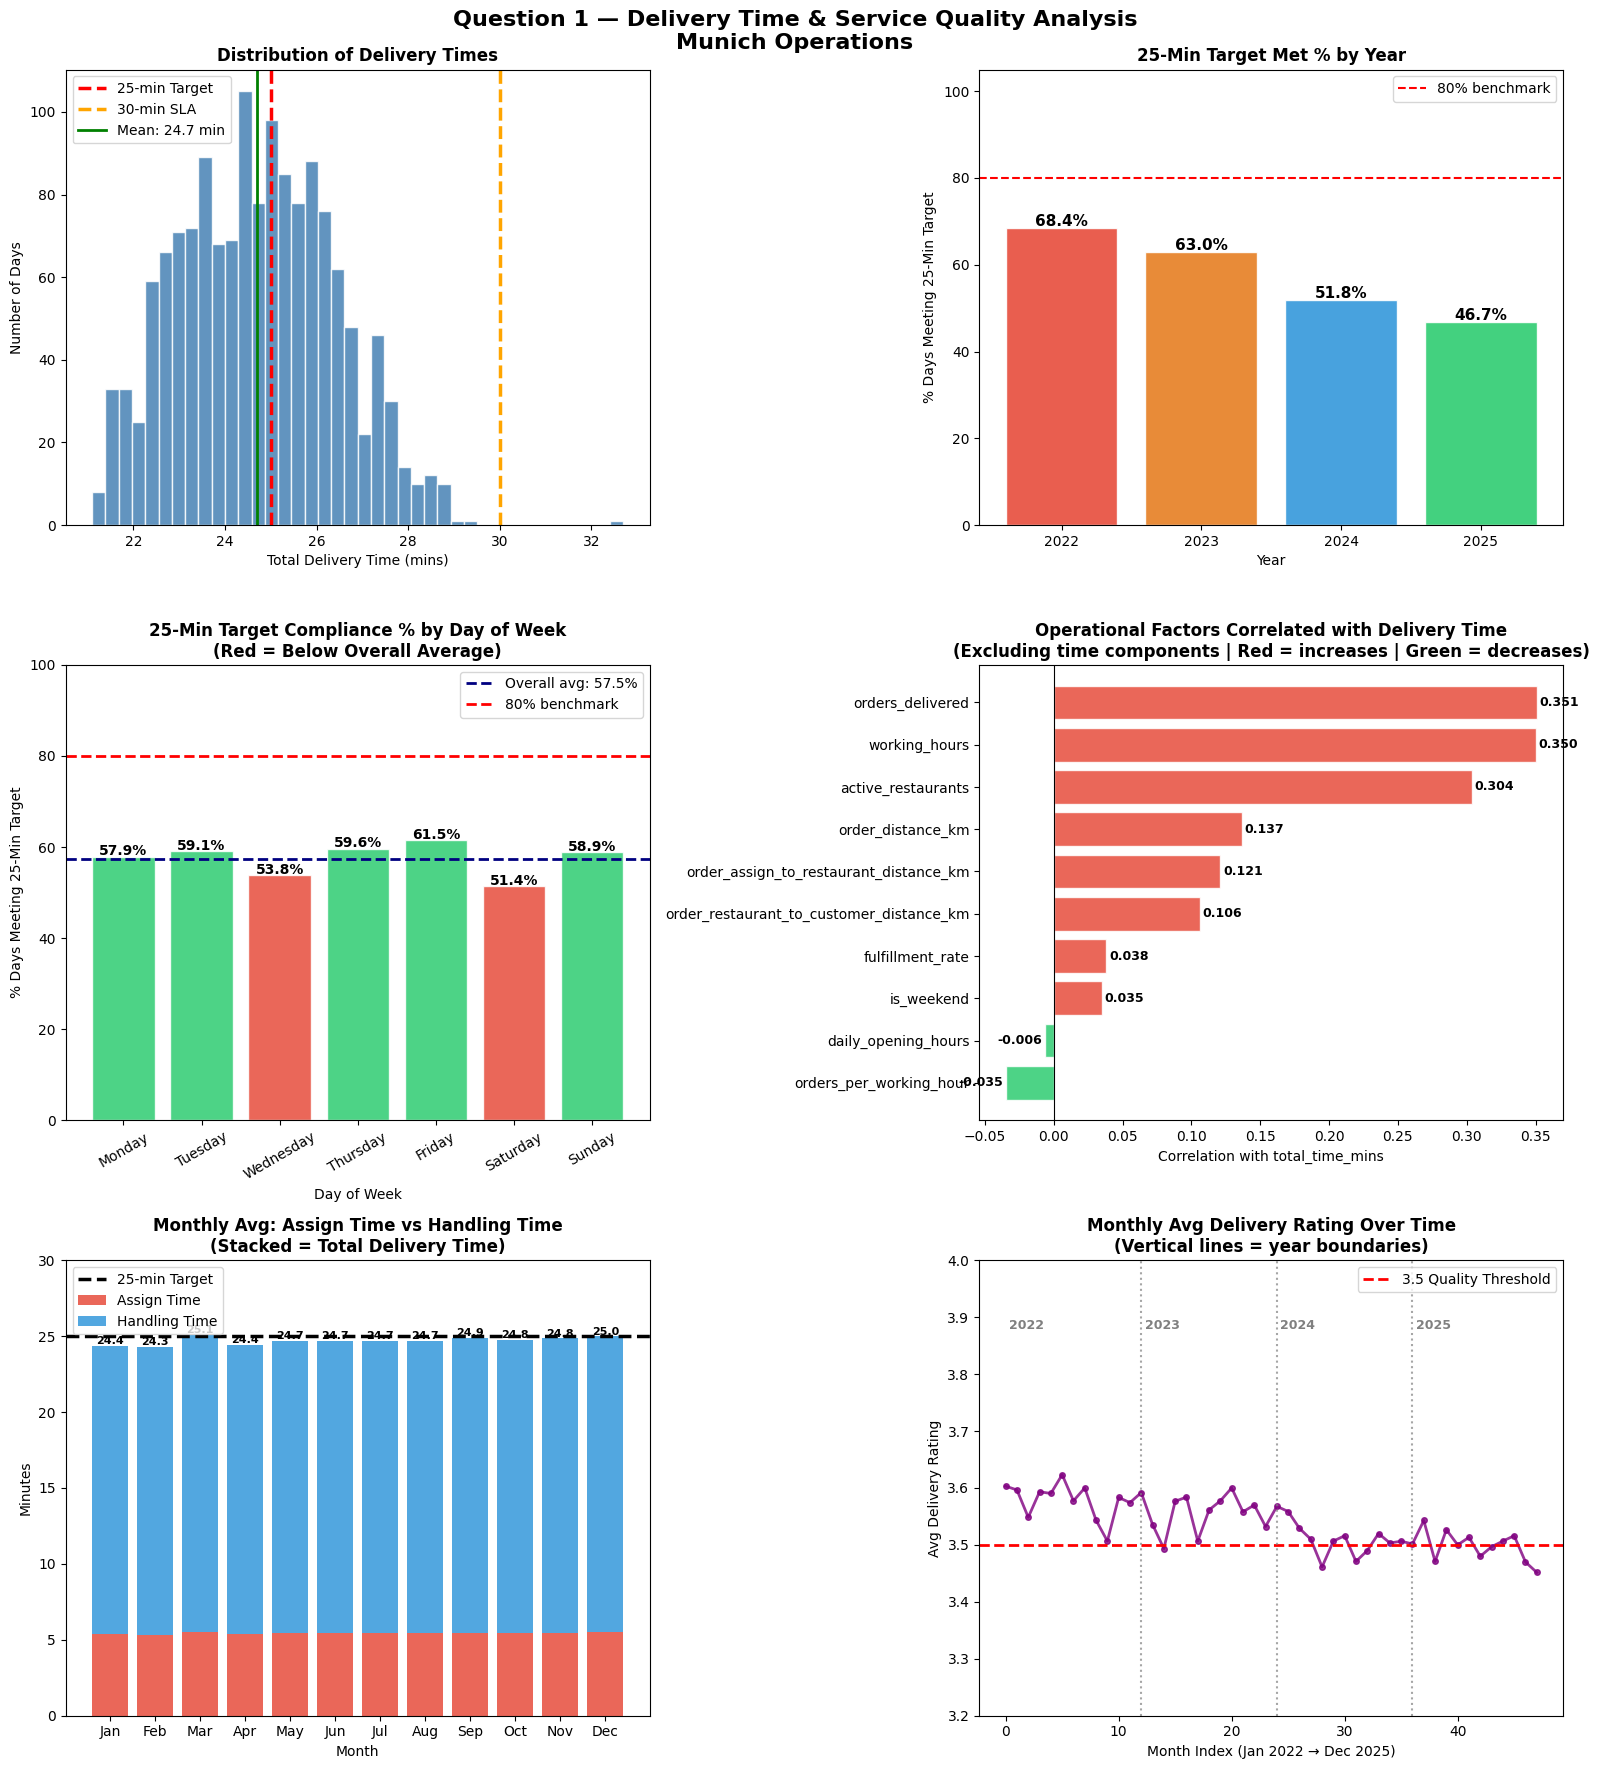

In [422]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Question 1 — Delivery Time & Service Quality Analysis\nMunich Operations',fontsize=16, fontweight='bold', y=0.98)

# PLOT 1: Distribution of total_time_mins
ax1 = axes[0, 0]
ax1.hist(df_clean['total_time_mins'], bins=40,color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(x=25, color='red',linewidth=2.5,linestyle='--', label='25-min Target')
ax1.axvline(x=30, color='orange', linewidth=2.5,linestyle='--', label='30-min SLA')
ax1.axvline(x=df_clean['total_time_mins'].mean(), color='green',linewidth=2, linestyle='-',label=f"Mean: {df_clean['total_time_mins'].mean():.1f} min")
ax1.set_title('Distribution of Delivery Times', fontweight='bold')
ax1.set_xlabel('Total Delivery Time (mins)')
ax1.set_ylabel('Number of Days')
ax1.legend()


# Plot 2 — break overall compliance down by year to see if trend is improving or declining

ax2 = axes[0, 1]
yearly_sla = df_clean.groupby('year')['sla_met_25'].mean() * 100
bars2 = ax2.bar(yearly_sla.index.astype(str), yearly_sla.values,color=['#e74c3c', '#e67e22', '#3498db', '#2ecc71'],edgecolor='white', alpha=0.9)
ax2.axhline(y=80, color='red', linestyle='--',linewidth=1.5, label='80% benchmark')
for bar, val in zip(bars2, yearly_sla.values):
    ax2.text(bar.get_x() + bar.get_width()/2,bar.get_height() + 0.5, f'{val:.1f}%',ha='center', fontweight='bold', fontsize=11)
ax2.set_title('25-Min Target Met % by Year', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('% Days Meeting 25-Min Target')
ax2.legend()
ax2.set_ylim(0, 105)

# Plot 3 — check if specific days of week consistently underperform
# red = below overall average, green = above, helps operations plan staffing by day
ax3 = axes[1, 0]
dow_order = ['Monday', 'Tuesday', 'Wednesday','Thursday', 'Friday', 'Saturday', 'Sunday']
dow_compliance = df_clean.groupby('day_of_week')['sla_met_25'].mean() * 100
dow_compliance = dow_compliance.reindex(dow_order)

overall_avg = df_clean['sla_met_25'].mean() * 100
colors_dow = ['#e74c3c' if v < overall_avg else '#2ecc71' for v in dow_compliance.values]

bars3 = ax3.bar(dow_compliance.index, dow_compliance.values,color=colors_dow, alpha=0.85, edgecolor='white')
ax3.axhline(y=overall_avg, color='navy', linestyle='--',linewidth=2, label=f'Overall avg: {overall_avg:.1f}%')
ax3.axhline(y=80, color='red', linestyle='--',linewidth=2, label='80% benchmark')
for bar, val in zip(bars3, dow_compliance.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
ax3.set_title('25-Min Target Compliance % by Day of Week\n(Red = Below Overall Average)',fontweight='bold')
ax3.set_xlabel('Day of Week')
ax3.set_ylabel('% Days Meeting 25-Min Target')
ax3.set_ylim(0, 100)
ax3.legend()
ax3.tick_params(axis='x', rotation=30)


# Plot 4 — rank operational factors by how strongly they correlate with delivery time


ax4 = axes[1, 1]
numeric_features = ['assign_time_mins','order_handling_time_mins','order_distance_km','order_restaurant_to_customer_distance_km','order_assign_to_restaurant_distance_km',
'working_hours','orders_delivered','active_restaurants','fulfillment_rate','orders_per_working_hour','is_weekend','daily_opening_hours']
corr_vals = df_clean[numeric_features + ['total_time_mins']].corr()['total_time_mins'].drop('total_time_mins').sort_values()

corr_vals_operational = corr_vals.drop(['order_handling_time_mins','assign_time_mins'])

colors_corr = ['#2ecc71' if v < 0 else '#e74c3c' for v in corr_vals_operational.values]
bars4 = ax4.barh(corr_vals_operational.index,corr_vals_operational.values,color=colors_corr, alpha=0.85, edgecolor='white')
ax4.axvline(x=0, color='black', linewidth=0.8)

for bar, val in zip(bars4, corr_vals_operational.values):
    ax4.text(val + 0.002 if val >= 0 else val - 0.002,
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center',
             ha='left' if val >= 0 else 'right',
             fontsize=9, fontweight='bold')

ax4.set_title('Operational Factors Correlated with Delivery Time\n'
        '(Excluding time components | Red = increases | Green = decreases)',
              fontweight='bold')
ax4.set_xlabel('Correlation with total_time_mins')

# Plot 5 - show how assign and handling time stack up each month
# helps identify if either component is seasonally worse than the other
ax5 = axes[2, 0]
months_data = df_clean.groupby('month')[['assign_time_mins', 'order_handling_time_mins']].mean()

bars5a = ax5.bar(months_data.index,months_data['assign_time_mins'],label='Assign Time', color='#e74c3c', alpha=0.85)
bars5b = ax5.bar(months_data.index,months_data['order_handling_time_mins'],bottom=months_data['assign_time_mins'],label='Handling Time', color='#3498db', alpha=0.85)

ax5.axhline(y=25, color='black', linestyle='--',linewidth=2.5, label='25-min Target')

for i, (idx, row) in enumerate(months_data.iterrows()):
    total = row['assign_time_mins'] + row['order_handling_time_mins']
    ax5.text(idx, total + 0.1, f'{total:.1f}',
             ha='center', fontsize=8, fontweight='bold')

ax5.set_title('Monthly Avg: Assign Time vs Handling Time\n'
              '(Stacked = Total Delivery Time)',
              fontweight='bold')
ax5.set_xlabel('Month')
ax5.set_ylabel('Minutes')
ax5.set_xticks(range(1, 13))
ax5.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun','Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax5.set_ylim(0, 30)
ax5.legend()

# Plot 6 - track rating month by month across all 4 years
# year boundary lines added so trend within and across years is easy to read
ax6 = axes[2, 1]
monthly_rating = df_clean.groupby(['year', 'month'])['delivery_rating'].mean().reset_index()
monthly_rating = monthly_rating.sort_values(['year', 'month'])
monthly_rating['period'] = range(len(monthly_rating))

ax6.plot(monthly_rating['period'], monthly_rating['delivery_rating'],color='purple', linewidth=2, marker='o', markersize=4, alpha=0.8)
ax6.axhline(y=3.5, color='red', linestyle='--',linewidth=2, label='3.5 Quality Threshold')

for year in [2023, 2024, 2025]:
    year_start = monthly_rating[
        monthly_rating['year'] == year]['period'].iloc[0]
    ax6.axvline(x=year_start, color='gray',
                linestyle=':', linewidth=1.5, alpha=0.7)
    ax6.text(year_start + 0.3, 3.88, str(year),
             fontsize=9, color='gray', fontweight='bold')

ax6.text(0.3, 3.88, '2022', fontsize=9,color='gray', fontweight='bold')
ax6.set_title('Monthly Avg Delivery Rating Over Time\n'
              '(Vertical lines = year boundaries)',
              fontweight='bold')
ax6.set_xlabel('Month Index (Jan 2022 → Dec 2025)')
ax6.set_ylabel('Avg Delivery Rating')
ax6.legend()
ax6.set_ylim(3.2, 4.0)

plt.tight_layout()
plt.savefig('q1_delivery_analysis_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# Question 2 : Impact of Working Hours on Order Fulfillment

In [423]:
corr_wh_fulfillment = df_clean['working_hours'].corr(df_clean['fulfillment_rate'])
corr_wh_orders      = df_clean['working_hours'].corr(df_clean['orders_delivered'])
corr_wh_lost        = df_clean['working_hours'].corr(df_clean['lost_orders'])
corr_wh_efficiency  = df_clean['working_hours'].corr(df_clean['orders_per_working_hour'])

print(f"working_hours vs fulfillment_rate: {corr_wh_fulfillment:+.3f}")
print(f"working_hours vs orders_delivered: {corr_wh_orders:+.3f}")
print(f"working_hours vs lost_orders: {corr_wh_lost:+.3f}")
print(f"working_hours vs orders_per_working_hour : {corr_wh_efficiency:+.3f}")

working_hours vs fulfillment_rate: +0.027
working_hours vs orders_delivered: +0.979
working_hours vs lost_orders: +0.587
working_hours vs orders_per_working_hour : -0.194


In [424]:
print("Working hours distribution:")
print(df_clean['working_hours'].describe().round(1))

print("\nFulfillment rate distribution:")
print(df_clean['fulfillment_rate'].describe().round(1))

Working hours distribution:
count   1458.00
mean    2238.80
std      444.10
min     1289.90
25%     1853.20
50%     2212.60
75%     2574.50
max     3792.10
Name: working_hours, dtype: float64

Fulfillment rate distribution:
count   1458.00
mean      85.20
std        3.10
min       80.00
25%       82.50
50%       85.00
75%       87.90
max       90.90
Name: fulfillment_rate, dtype: float64


In [425]:
# Percentile bands ensure equal group sizes 
df_clean['wh_band'] = pd.qcut(
    df_clean['working_hours'],
    q=5,
    labels=['Very Low(<20%)',
            'Low(20-40%)',
            'Medium(40-60%)',
            'High(60-80%)',
            'Very High(>80%)']
)

df_clean.groupby('wh_band', observed=True).agg(
    avg_working_hours    = ('working_hours','mean'),
    avg_fulfillment_rate = ('fulfillment_rate','mean'),
    avg_lost_orders      = ('lost_orders','mean'),
    avg_orders_delivered = ('orders_delivered','mean'),
    avg_potential        = ('potential','mean'),
    avg_total_time       = ('total_time_mins','mean'),
    avg_efficiency       = ('orders_per_working_hour','mean'),
    day_count            = ('orders_delivered','count')
).round(2)

,avg_working_hours,avg_fulfillment_rate,avg_lost_orders,avg_orders_delivered,avg_potential,avg_total_time,avg_efficiency,day_count
wh_band,,,,,,,,
Very Low(<20%),1660.71,85.03,641.92,3616.89,4258.82,23.83,2.18,292
Low(20-40%),1949.82,85.33,727.05,4195.23,4922.28,24.38,2.15,291
Medium(40-60%),2213.23,85.18,836.18,4769.79,5605.97,24.71,2.16,292
High(60-80%),2471.08,85.28,914.71,5266.29,6181.00,25.22,2.13,291
Very High(>80%),2898.92,85.22,1076.36,6146.02,7222.37,25.39,2.12,292


In [426]:
df_clean.groupby('year').agg(
    avg_working_hours    = ('working_hours','mean'),
    avg_fulfillment_rate = ('fulfillment_rate','mean'),
    avg_lost_orders      = ('lost_orders','mean'),
    avg_orders_delivered = ('orders_delivered','mean'),
    avg_potential        = ('potential','mean'),
    avg_efficiency       = ('orders_per_working_hour','mean'),
    total_lost_orders    = ('lost_orders','sum')
).round(2)

,avg_working_hours,avg_fulfillment_rate,avg_lost_orders,avg_orders_delivered,avg_potential,avg_efficiency,total_lost_orders
year,,,,,,,
2022,1829.54,85.17,689.00,3920.51,4609.51,2.15,250796
2023,2015.30,85.07,764.52,4328.47,5093.00,2.15,279051
2024,2486.14,85.28,929.17,5336.70,6265.87,2.15,339147
2025,2624.12,85.31,974.34,5609.88,6584.22,2.14,354660


In [427]:
weekend_wh = df_clean.groupby('is_weekend').agg(
    avg_working_hours = ('working_hours','mean'),
    avg_fulfillment_rate = ('fulfillment_rate','mean'),
    avg_lost_orders = ('lost_orders','mean'),
    avg_potential = ('potential','mean'),
    avg_efficiency = ('orders_per_working_hour','mean'),
    avg_total_time = ('total_time_mins','mean')
).round(2)

weekend_wh.index = ['Weekday', 'Weekend']
weekend_wh

,avg_working_hours,avg_fulfillment_rate,avg_lost_orders,avg_potential,avg_efficiency,avg_total_time
Weekday,2148.53,85.08,812.76,5415.03,2.15,24.67
Weekend,2464.13,85.52,905.43,6195.34,2.15,24.80


In [428]:
# Bottom 10% fulfillment days — checking if working hours or demand is the differentiator
low_threshold = df_clean['fulfillment_rate'].quantile(0.10)
low_days      = df_clean[df_clean['fulfillment_rate'] <= low_threshold]
other_days    = df_clean[df_clean['fulfillment_rate'] >  low_threshold]

print(f"Low fulfillment threshold (bottom 10%): {low_threshold:.1f}%")
print(f"Days in this group: {len(low_days)}")

print(f"\nAvg working hours — low fulfillment days : {low_days['working_hours'].mean():.1f}")
print(f"Avg working hours — all other days: {other_days['working_hours'].mean():.1f}")

print(f"\nAvg potential — low fulfillment days: {low_days['potential'].mean():.1f}")
print(f"Avg potential — all other days: {other_days['potential'].mean():.1f}")

df_clean.nsmallest(10, 'fulfillment_rate')[
    ['date', 'day_of_week', 'year', 'fulfillment_rate',
     'working_hours', 'orders_delivered', 'potential',
     'lost_orders', 'orders_per_working_hour']
].round(2).reset_index(drop=True)

Low fulfillment threshold (bottom 10%): 81.0%
Days in this group: 149

Avg working hours — low fulfillment days : 2205.1
Avg working hours — all other days: 2242.6

Avg potential — low fulfillment days: 5843.9
Avg potential — all other days: 5614.8


,date,day_of_week,year,fulfillment_rate,working_hours,orders_delivered,potential,lost_orders,orders_per_working_hour
0,2024-01-28,Sunday,2024,80.00,2322.40,4657,5821,1164,2.00
1,2023-09-08,Friday,2023,80.01,2312.70,4738,5922,1184,2.05
2,2024-03-25,Monday,2024,80.02,2042.80,4486,5606,1120,2.20
3,2023-10-28,Saturday,2023,80.03,2278.30,4780,5973,1193,2.10
4,2022-06-02,Thursday,2022,80.05,1504.00,3138,3920,782,2.09
5,2025-08-16,Saturday,2025,80.05,2903.40,5926,7403,1477,2.04
6,2023-12-23,Saturday,2023,80.06,2180.40,4601,5747,1146,2.11
7,2024-04-16,Tuesday,2024,80.06,2225.00,4686,5853,1167,2.11
8,2024-07-25,Thursday,2024,80.07,2194.00,4998,6242,1244,2.28
9,2023-01-31,Tuesday,2023,80.09,1700.80,3822,4772,950,2.25


## Question 2 : Regression and What Actually Drives Fulfillment

In [429]:
from sklearn.linear_model import LinearRegression

X = df_clean[['working_hours']]
y = df_clean['fulfillment_rate']

model_wh = LinearRegression()
model_wh.fit(X, y)

print(f"fulfillment_rate = {model_wh.intercept_:.4f} + " f"{model_wh.coef_[0]:.6f} × working_hours")
print(f"R² score : {model_wh.score(X, y):.4f}")
print(f"\nFor every +100 working hours added, fulfillment changes by: " f"{model_wh.coef_[0] * 100:.4f} percentage points")

fulfillment_rate = 84.7756 + 0.000194 × working_hours
R² score : 0.0008

For every +100 working hours added, fulfillment changes by: 0.0194 percentage points


In [430]:
# working_hours explains almost nothing — find what actually does
fulfillment_drivers = [
    'working_hours',
    'potential',
    'orders_delivered',
    'active_restaurants',
    'daily_online_restaurants',
    'order_distance_km',
    'total_time_mins',
    'orders_per_working_hour',
    'is_weekend',
    'daily_opening_hours',
    'delivery_area_km2'
]

df_clean[fulfillment_drivers + ['fulfillment_rate']].corr()['fulfillment_rate'].drop('fulfillment_rate').sort_values()

potential                  -0.15
order_distance_km           0.02
working_hours               0.03
daily_online_restaurants    0.03
active_restaurants          0.03
daily_opening_hours         0.03
delivery_area_km2           0.03
orders_delivered            0.03
total_time_mins             0.04
orders_per_working_hour     0.04
is_weekend                  0.06
Name: fulfillment_rate, dtype: float64

In [432]:
# absolute lost orders  
df_clean.groupby('year')['lost_orders'].agg(
    ['sum', 'mean', 'min', 'max']
).round(0).rename(columns={
    'sum'  : 'Total Lost',
    'mean' : 'Avg Daily Lost',
    'min'  : 'Min Daily Lost',
    'max'  : 'Max Daily Lost'
})

,Total Lost,Avg Daily Lost,Min Daily Lost,Max Daily Lost
year,,,,
2022,250796,689.00,342,1271
2023,279051,765.00,377,1318
2024,339147,929.00,380,1665
2025,354660,974.00,494,1642


## Question 2 : Analysis Chart

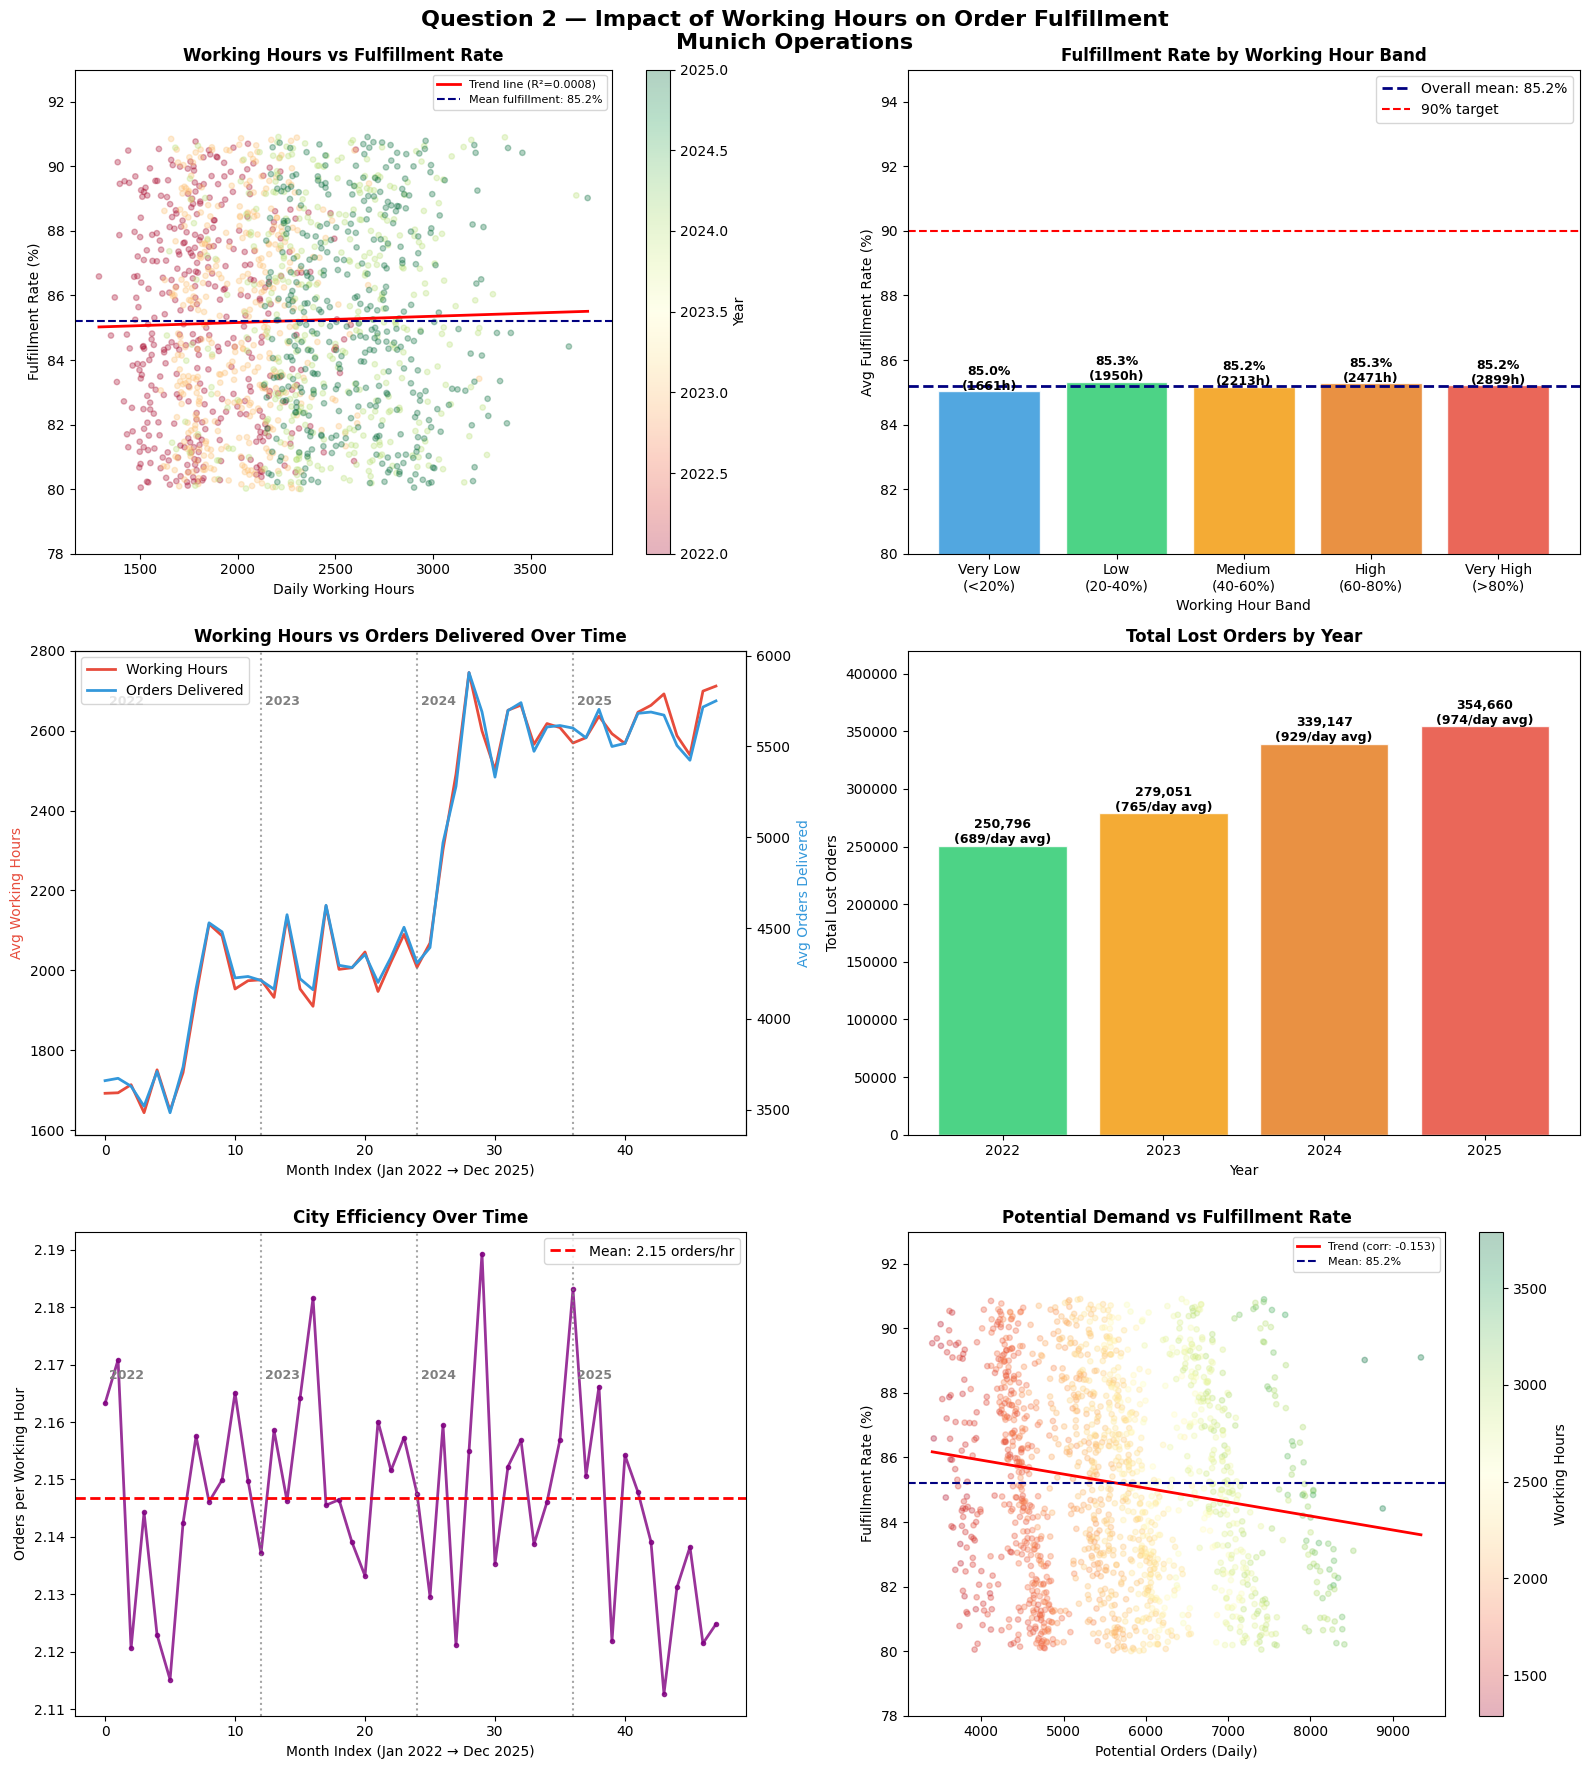

In [433]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Question 2 — Impact of Working Hours on Order Fulfillment\nMunich Operations',fontsize=16, fontweight='bold', y=0.98)

# Plot 1 — scatter working hours against fulfillment to see if any pattern exists
# colour by year to check if the relationship changed over time
ax1 = axes[0, 0]
scatter = ax1.scatter(df_clean['working_hours'],
                      df_clean['fulfillment_rate'],
                      alpha=0.3, c=df_clean['year'],
                      cmap='RdYlGn', s=15)
plt.colorbar(scatter, ax=ax1, label='Year')

x_range = np.linspace(df_clean['working_hours'].min(),df_clean['working_hours'].max(), 100)
y_pred  = model_wh.intercept_ + model_wh.coef_[0] * x_range
ax1.plot(x_range, y_pred, color='red', linewidth=2,label=f'Trend line (R²={model_wh.score(X, y):.4f})')
ax1.axhline(y=df_clean['fulfillment_rate'].mean(), color='navy',linestyle='--', linewidth=1.5,label=f"Mean fulfillment: {df_clean['fulfillment_rate'].mean():.1f}%")
ax1.set_title('Working Hours vs Fulfillment Rate',
              fontweight='bold')
ax1.set_xlabel('Daily Working Hours')
ax1.set_ylabel('Fulfillment Rate (%)')
ax1.legend(fontsize=8)
ax1.set_ylim(78, 93)

# Plot 2 — split days into five working hour bands and compare fulfillment across them
ax2 = axes[0, 1]
band_labels= ['Very Low\n(<20%)', 'Low\n(20-40%)','Medium\n(40-60%)', 'High\n(60-80%)', 'Very High\n(>80%)']
band_fulfillment = [85.03, 85.33, 85.18, 85.28, 85.22]
band_hours       = [1660.71, 1949.82, 2213.23, 2471.08, 2898.92]
color_bands      = ['#3498db', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

bars2 = ax2.bar(band_labels, band_fulfillment,color=color_bands, alpha=0.85, edgecolor='white')
ax2.axhline(y=df_clean['fulfillment_rate'].mean(), color='navy',linestyle='--', linewidth=2,label=f"Overall mean: {df_clean['fulfillment_rate'].mean():.1f}%")
ax2.axhline(y=90, color='red', linestyle='--',linewidth=1.5, label='90% target')

for bar, val, hrs in zip(bars2, band_fulfillment, band_hours):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f'{val:.1f}%\n({hrs:.0f}h)',
             ha='center', fontsize=9, fontweight='bold')

ax2.set_title('Fulfillment Rate by Working Hour Band',fontweight='bold')
ax2.set_xlabel('Working Hour Band')
ax2.set_ylabel('Avg Fulfillment Rate (%)')
ax2.set_ylim(80, 95)
ax2.legend()

# Plot 3 — track working hours and orders delivered on same timeline
ax3 = axes[1, 0]
monthly_data = df_clean.groupby(['year', 'month']).agg(
    avg_working_hours = ('working_hours',    'mean'),
    avg_orders        = ('orders_delivered', 'mean')
).reset_index().sort_values(['year', 'month'])
monthly_data['period'] = range(len(monthly_data))

ax3_twin = ax3.twinx()
line1 = ax3.plot(monthly_data['period'],monthly_data['avg_working_hours'],color='#e74c3c', linewidth=2, label='Working Hours')
line2 = ax3_twin.plot(monthly_data['period'],monthly_data['avg_orders'],color='#3498db', linewidth=2, label='Orders Delivered')

for year in [2023, 2024, 2025]:
    yr_start = monthly_data[monthly_data['year'] == year]['period'].iloc[0]
    ax3.axvline(x=yr_start, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
    ax3.text(yr_start + 0.3,
             monthly_data['avg_working_hours'].max() * 0.97,
             str(year), fontsize=9, color='gray', fontweight='bold')

ax3.text(0.3, monthly_data['avg_working_hours'].max() * 0.97,'2022', fontsize=9, color='gray', fontweight='bold')
ax3.set_title('Working Hours vs Orders Delivered Over Time', fontweight='bold')
ax3.set_xlabel('Month Index (Jan 2022 → Dec 2025)')
ax3.set_ylabel('Avg Working Hours', color='#e74c3c')
ax3_twin.set_ylabel('Avg Orders Delivered', color='#3498db')
lines  = line1 + line2
labels = [l.get_label() for l in lines]
ax3.legend(lines, labels, loc='upper left')

# Plot 4 — yearly total of lost orders to quantify the business cost
ax4 = axes[1, 1]
yearly_lost_data = df_clean.groupby('year').agg(
    total_lost     = ('lost_orders', 'sum'),
    avg_daily_lost = ('lost_orders', 'mean')
).round(0)

bars4 = ax4.bar(yearly_lost_data.index.astype(str),
                yearly_lost_data['total_lost'],
                color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'],
                alpha=0.85, edgecolor='white')

for bar, (_, row) in zip(bars4, yearly_lost_data.iterrows()):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2000,
             f"{row['total_lost']:,.0f}\n({row['avg_daily_lost']:.0f}/day avg)",
             ha='center', fontsize=9, fontweight='bold')

ax4.set_title('Total Lost Orders by Year',fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Total Lost Orders')
ax4.set_ylim(0, 420000)

# Plot 5 — track orders per working hour over time
ax5 = axes[2, 0]
monthly_eff = df_clean.groupby(['year', 'month']).agg(
    avg_efficiency = ('orders_per_working_hour', 'mean')
).reset_index().sort_values(['year', 'month'])
monthly_eff['period'] = range(len(monthly_eff))

ax5.plot(monthly_eff['period'], monthly_eff['avg_efficiency'],color='purple', linewidth=2, marker='o', markersize=3, alpha=0.8)
ax5.axhline(y=monthly_eff['avg_efficiency'].mean(), color='red',linestyle='--', linewidth=2,label=f"Mean: {monthly_eff['avg_efficiency'].mean():.2f} orders/hr")

for year in [2023, 2024, 2025]:
    yr_start = monthly_eff[monthly_eff['year'] == year]['period'].iloc[0]
    ax5.axvline(x=yr_start, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
    ax5.text(yr_start + 0.3,
             monthly_eff['avg_efficiency'].max() * 0.99,
             str(year), fontsize=9, color='gray', fontweight='bold')

ax5.text(0.3, monthly_eff['avg_efficiency'].max() * 0.99,'2022', fontsize=9, color='gray', fontweight='bold')
ax5.set_title('City Efficiency Over Time',fontweight='bold')
ax5.set_xlabel('Month Index (Jan 2022 → Dec 2025)')
ax5.set_ylabel('Orders per Working Hour')
ax5.legend()

# Plot 6 — scatter potential demand against fulfillment rate
ax6 = axes[2, 1]
scatter6 = ax6.scatter(df_clean['potential'],
                       df_clean['fulfillment_rate'],
                       alpha=0.3, c=df_clean['working_hours'],
                       cmap='RdYlGn', s=15)
plt.colorbar(scatter6, ax=ax6, label='Working Hours')

z= np.polyfit(df_clean['potential'], df_clean['fulfillment_rate'], 1)
p= np.poly1d(z)
x_sorted = np.sort(df_clean['potential'])
corr_pot = df_clean['potential'].corr(df_clean['fulfillment_rate'])

ax6.plot(x_sorted, p(x_sorted), color='red', linewidth=2,label=f'Trend (corr: {corr_pot:.3f})')
ax6.axhline(y=df_clean['fulfillment_rate'].mean(), color='navy',linestyle='--', linewidth=1.5,label=f"Mean: {df_clean['fulfillment_rate'].mean():.1f}%")
ax6.set_title('Potential Demand vs Fulfillment Rate',fontweight='bold')
ax6.set_xlabel('Potential Orders (Daily)')
ax6.set_ylabel('Fulfillment Rate (%)')
ax6.legend(fontsize=8)
ax6.set_ylim(78, 93)

plt.tight_layout()
plt.savefig('q2_working_hours_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Question 3 : Order Volume Forecast (120 Days)

In [434]:
from prophet import Prophet
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.patches as mpatches

# 3 rows were removed during cleaning, leaving date gaps
# ffill fills those 3 dates with the prior day's value
ts_df = df_clean[['date', 'orders_delivered']].copy()
ts_df = ts_df.sort_values('date').reset_index(drop=True)
ts_df['date'] = pd.to_datetime(ts_df['date'])
ts_df = ts_df.set_index('date').asfreq('D', method='ffill')

date_range_full = pd.date_range(start=ts_df.index.min(),end=ts_df.index.max(),freq='D')
missing_dates = date_range_full.difference(ts_df.index)

print(f"Series length : {len(ts_df)} days")
print(f"Date range    : {ts_df.index.min().date()} → {ts_df.index.max().date()}")
print(f"Missing dates : {len(missing_dates)}")
print(f"Orders mean   : {ts_df['orders_delivered'].mean():.0f}")
print(f"Orders min    : {ts_df['orders_delivered'].min():.0f}")
print(f"Orders max    : {ts_df['orders_delivered'].max():.0f}")

Series length : 1461 days
Date range    : 2022-01-01 → 2025-12-31
Missing dates : 0
Orders mean   : 4799
Orders min    : 2965
Orders max    : 8324


In [435]:
# ADF test determines whether differencing is needed before fitting SARIMA
# p-value < 0.05 = stationary (d=0), p-value >= 0.05 = non-stationary (d=1)
adf_result = adfuller(ts_df['orders_delivered'].dropna())

print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")

d_param = 0 if adf_result[1] < 0.05 else 1
print(f"\nd parameter for SARIMA: {d_param}")

ADF Statistic : -1.6785
p-value: 0.4422

d parameter for SARIMA: 1


In [436]:
# Decompose into trend, seasonal and residual components

decomposition = seasonal_decompose(
    ts_df['orders_delivered'],
    model='additive',
    period=7
)

trend_comp = decomposition.trend.dropna()
seasonal_comp = decomposition.seasonal
resid_comp    = decomposition.resid.dropna()

trend_strength = max(0, 1 - (resid_comp.var() / (trend_comp + resid_comp).var()))
seasonal_strength = max(0, 1 - (resid_comp.var() / (seasonal_comp + resid_comp).var()))

print(f"Trend Strength : {trend_strength:.3f}   (>0.6 = strong)")
print(f"Seasonal Strength : {seasonal_strength:.3f}   (>0.6 = strong)")
print(f"Trend Growth  : {trend_comp.iloc[0]:.0f} -> " f"{trend_comp.iloc[-1]:.0f} orders/day")
print(f"Seasonal Swing: {seasonal_comp.min():.0f} to " f"+{seasonal_comp.max():.0f} orders")

Trend Strength : 0.929   (>0.6 = strong)
Seasonal Strength : 0.781   (>0.6 = strong)
Trend Growth  : 3719 -> 5999 orders/day
Seasonal Swing: -376 to +509 orders


In [437]:
# same window used for all models to keep comparison fair
test_size = 120
train = ts_df['orders_delivered'].iloc[:-test_size]
test  = ts_df['orders_delivered'].iloc[-test_size:]

print(f"Training : {train.index.min().date()} → {train.index.max().date()} ({len(train)} days)")
print(f"Test: {test.index.min().date()} → {test.index.max().date()} ({len(test)} days)")
print(f"Training mean : {train.mean():.0f} orders/day")
print(f"Test mean: {test.mean():.0f} orders/day")

# Prophet requires its own dataframe format with ds and y columns
prophet_train = pd.DataFrame({'ds': train.index, 'y': train.values})
prophet_full  = pd.DataFrame({'ds': ts_df.index,'y': ts_df['orders_delivered'].values})

Training : 2022-01-01 → 2025-09-02 (1341 days)
Test: 2025-09-03 → 2025-12-31 (120 days)
Training mean : 4726 orders/day
Test mean: 5609 orders/day


## Question 3 : Model Fitting and Validation

In [438]:
# Holt-Winters
# optimized=True lets statsmodels tune alpha, beta, gamma and phi automatically
hw_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=7,
    damped_trend=True
)
hw_fit  = hw_model.fit(optimized=True)
hw_pred = hw_fit.forecast(test_size)

hw_mae  = mean_absolute_error(test, hw_pred)
hw_rmse = np.sqrt(mean_squared_error(test, hw_pred))
hw_mape = np.mean(np.abs((test.values - hw_pred.values) / test.values)) * 100

print(f"Smoothing parameters (auto-tuned):")
print(f"Alpha (level)    : {hw_fit.params['smoothing_level']:.4f}")
print(f"Beta  (trend)    : {hw_fit.params['smoothing_trend']:.4f}")
print(f"Gamma (seasonal) : {hw_fit.params['smoothing_seasonal']:.4f}")
print(f"Phi   (damping)  : {hw_fit.params['damping_trend']:.4f}")
print(f"\nValidation on 120-day test set:")
print(f"MAE  : {hw_mae:.0f} orders")
print(f"RMSE : {hw_rmse:.0f} orders")
print(f"MAPE : {hw_mape:.2f}%")

Smoothing parameters (auto-tuned):
Alpha (level)    : 0.5677
Beta  (trend)    : 0.0000
Gamma (seasonal) : 0.0327
Phi   (damping)  : 0.8000

Validation on 120-day test set:
MAE  : 280 orders
RMSE : 414 orders
MAPE : 4.70%


In [439]:
#Prophet

import random
random.seed(42)
np.random.seed(42)

# yearly_seasonality=False — 4 years insufficient to learn reliable yearly patterns
# weekly_seasonality=True  — confirmed from decomposition (seasonal strength 0.781)
# changepoint_prior_scale=0.05 — conservative, reduces overfitting to noise
prophet_model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
prophet_model.fit(prophet_train)

prophet_test_future = prophet_model.make_future_dataframe(periods=test_size, freq='D')
prophet_test_forecast = prophet_model.predict(prophet_test_future)
prophet_pred= prophet_test_forecast['yhat'].iloc[-test_size:].values

prophet_mae  = mean_absolute_error(test.values, prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(test.values, prophet_pred))
prophet_mape = np.mean(np.abs((test.values - prophet_pred) / test.values)) * 100

print(f"Validation on 120-day test set:")
print(f"  MAE  : {prophet_mae:.0f} orders")
print(f"  RMSE : {prophet_rmse:.0f} orders")
print(f"  MAPE : {prophet_mape:.2f}%")

16:33:52 - cmdstanpy - INFO - Chain [1] start processing
16:33:53 - cmdstanpy - INFO - Chain [1] done processing


Validation on 120-day test set:
  MAE  : 338 orders
  RMSE : 413 orders
  MAPE : 5.95%


In [440]:
# SARIMA(1,1,1)(1,1,1,7)
# p=1 — one autoregressive lag, each day partially explained by the prior day
# d=1 — first differencing, confirmed by ADF test p-value 0.4422
# q=1 — one moving average term, corrects for one lag of forecast error
# Seasonal (1,1,1,7) — same three-parameter structure applied to the 7-day cycle
# Standard starting point for daily business data with confirmed weekly seasonality
sarima_model = SARIMAX(
    train,
    order=(1, d_param, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit  = sarima_model.fit(disp=False)
sarima_pred = sarima_fit.forecast(steps=test_size)

sarima_mae  = mean_absolute_error(test, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_pred))
sarima_mape = np.mean(np.abs((test.values - sarima_pred.values) / test.values)) * 100

print(f"Model diagnostics:")
print(f"AIC : {sarima_fit.aic:.2f}")
print(f"BIC : {sarima_fit.bic:.2f}")
print(f"\nValidation on 120-day test set:")
print(f"MAE  : {sarima_mae:.0f} orders")
print(f"RMSE : {sarima_rmse:.0f} orders")
print(f"MAPE : {sarima_mape:.2f}%")

Model diagnostics:
AIC : 18678.39
BIC : 18704.33

Validation on 120-day test set:
MAE  : 366 orders
RMSE : 403 orders
MAPE : 6.51%


In [441]:
# Ensemble : Simple average of all three models
# combined predictions sometimes cancel out individual model weaknesses
ensemble_pred = (hw_pred.values + prophet_pred + sarima_pred.values) / 3

ensemble_mae  = mean_absolute_error(test.values, ensemble_pred)
ensemble_rmse = np.sqrt(mean_squared_error(test.values, ensemble_pred))
ensemble_mape = np.mean(np.abs((test.values - ensemble_pred) / test.values)) * 100

print(f"Ensemble = (Holt-Winters + Prophet + SARIMA) / 3")
print(f"\nValidation on 120-day test set:")
print(f"  MAE  : {ensemble_mae:.0f} orders")
print(f"  RMSE : {ensemble_rmse:.0f} orders")
print(f"  MAPE : {ensemble_mape:.2f}%")

Ensemble = (Holt-Winters + Prophet + SARIMA) / 3

Validation on 120-day test set:
  MAE  : 325 orders
  RMSE : 397 orders
  MAPE : 5.66%


In [442]:
# Compare all four on same 120-day test set
# MAPE chosen as primary metric — scale-independent and directly interpretable
results = {
    'Holt-Winters' : {'MAE': hw_mae,      'RMSE': hw_rmse,       'MAPE': hw_mape},
    'Prophet'      : {'MAE': prophet_mae,  'RMSE': prophet_rmse, 'MAPE': prophet_mape},
    'Ensemble'     : {'MAE': ensemble_mae, 'RMSE': ensemble_rmse,'MAPE': ensemble_mape},
    'SARIMA'       : {'MAE': sarima_mae,   'RMSE': sarima_rmse,  'MAPE': sarima_mape}
}

print(f"{'Model':<20} {'MAE':>10} {'RMSE':>10} {'MAPE':>10}")
print("-" * 55)
for model, metrics in sorted(results.items(), key=lambda x: x[1]['MAPE']):
    print(f"{model:<20} {metrics['MAE']:>10.0f} "
          f"{metrics['RMSE']:>10.0f} {metrics['MAPE']:>9.2f}%")

best_model_name = min(results, key=lambda x: results[x]['MAPE'])
best_mape       = results[best_model_name]['MAPE']
print(f"\nWinner: {best_model_name} (MAPE: {best_mape:.2f}%)")

Model                       MAE       RMSE       MAPE
-------------------------------------------------------
Holt-Winters                280        414      4.70%
Ensemble                    325        397      5.66%
Prophet                     338        413      5.95%
SARIMA                      366        403      6.51%

Winner: Holt-Winters (MAPE: 4.70%)


In [443]:
# Refit winner on complete 1,461-day dataset before forecasting
forecast_days  = 120
forecast_start = ts_df.index.max() + pd.Timedelta(days=1)
forecast_end   = forecast_start + pd.Timedelta(days=forecast_days - 1)
forecast_index = pd.date_range(start=forecast_start,periods=forecast_days, freq='D')

print(f"Forecast period: {forecast_start.date()} -> {forecast_end.date()}")

if best_model_name == "Holt-Winters":
    final_model = ExponentialSmoothing(
        ts_df['orders_delivered'],
        trend='add', seasonal='add',
        seasonal_periods=7, damped_trend=True
    ).fit(optimized=True)

    _fc = final_model.forecast(forecast_days)
    forecast_values = np.array(_fc.values, dtype=float)
    residuals = ts_df['orders_delivered'].values - final_model.fittedvalues.values
    residual_std = float(np.std(residuals))

elif best_model_name == "Prophet":
    random.seed(42)
    np.random.seed(42)
    final_model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05
    )
    final_model.fit(prophet_full)
    future= final_model.make_future_dataframe(periods=forecast_days, freq='D')
    _fc= final_model.predict(future)
    forecast_values = np.array(_fc['yhat'].iloc[-forecast_days:].values, dtype=float)
    _fitted= final_model.predict(prophet_full)
    residuals = ts_df['orders_delivered'].values - _fitted['yhat'].values
    residual_std = float(np.std(residuals))

else:
    final_model = SARIMAX(
        ts_df['orders_delivered'],
        order=(1, d_param, 1),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
    _fc = final_model.get_forecast(steps=forecast_days)
    forecast_values = np.array(_fc.predicted_mean.values, dtype=float)
    residuals = ts_df['orders_delivered'].values - final_model.fittedvalues.values
    residual_std = float(np.std(residuals))

# Fixed-width confidence interval - ±1.96 standard deviations, same width every day
ci_margin      = 1.96 * residual_std
forecast_lower = forecast_values - ci_margin
forecast_upper = forecast_values + ci_margin

print(f"Mean forecast : {forecast_values.mean():.0f} orders/day")
print(f"Min forecast  : {forecast_values.min():.0f} orders/day")
print(f"Max forecast  : {forecast_values.max():.0f} orders/day")
print(f"CI margin     : ±{ci_margin:.0f} orders")

Forecast period: 2026-01-01 -> 2026-04-30
Mean forecast : 5498 orders/day
Min forecast  : 5021 orders/day
Max forecast  : 6123 orders/day
CI margin     : ±561 orders


In [444]:
forecast_df = pd.DataFrame({
    'date'    : forecast_index,
    'forecast': forecast_values,
    'lower'   : forecast_lower,
    'upper'   : forecast_upper
})
forecast_df['month']       = forecast_df['date'].dt.strftime('%b %Y')
forecast_df['day_of_week'] = forecast_df['date'].dt.day_name()

month_order = ['Jan 2026', 'Feb 2026', 'Mar 2026', 'Apr 2026']

forecast_df.groupby('month').agg(
    days             = ('forecast', 'count'),
    avg_daily_orders = ('forecast', 'mean'),
    min_daily        = ('forecast', 'min'),
    max_daily        = ('forecast', 'max'),
    total_orders     = ('forecast', 'sum')
).round(0).reindex(month_order)

,days,avg_daily_orders,min_daily,max_daily,total_orders
month,,,,,
Jan 2026,31,5528.00,5021.00,6123.00,171381.00
Feb 2026,28,5501.00,5021.00,6123.00,154029.00
Mar 2026,31,5487.00,5021.00,6123.00,170112.00
Apr 2026,30,5475.00,5021.00,6123.00,164238.00


In [445]:
forecast_df[['date', 'day_of_week', 'forecast','lower', 'upper']].round(0).reset_index(drop=True)

,date,day_of_week,forecast,lower,upper
0,2026-01-01,Thursday,5137.00,4577.00,5698.00
1,2026-01-02,Friday,6123.00,5563.00,6684.00
2,2026-01-03,Saturday,6092.00,5531.00,6652.00
3,2026-01-04,Sunday,6028.00,5467.00,6588.00
4,2026-01-05,Monday,5034.00,4474.00,5595.00
...,...,...,...,...,...
115,2026-04-26,Sunday,6028.00,5467.00,6588.00
116,2026-04-27,Monday,5034.00,4474.00,5595.00
117,2026-04-28,Tuesday,5021.00,4460.00,5582.00
118,2026-04-29,Wednesday,5072.00,4511.00,5632.00


In [446]:
# 95% confidence interval — base ± 1.96 standard deviations of model residuals
base = float(forecast_df['forecast'].mean())
pessimistic = base - ci_margin
optimistic  = base + ci_margin

print(f"Pessimistic : {pessimistic:,.0f} orders/day")
print(f"Base        : {base:,.0f} orders/day")
print(f"Optimistic  : {optimistic:,.0f} orders/day")
print(f"\nResidual std : {residual_std:.0f} orders")
print(f"Width        : ±{ci_margin:.0f} orders")

Pessimistic : 4,937 orders/day
Base        : 5,498 orders/day
Optimistic  : 6,059 orders/day

Residual std : 286 orders
Width        : ±561 orders


In [447]:
random.seed(42)
np.random.seed(42)

final_prophet_chart = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
final_prophet_chart.fit(prophet_full)

prophet_future= final_prophet_chart.make_future_dataframe(
                        periods=forecast_days, freq='D')
prophet_fc_full= final_prophet_chart.predict(prophet_future)
prophet_fc_values = np.array(
    prophet_fc_full['yhat'].iloc[-forecast_days:].values, dtype=float)

16:34:26 - cmdstanpy - INFO - Chain [1] start processing
16:34:26 - cmdstanpy - INFO - Chain [1] done processing


In [448]:
sarima_full_model = SARIMAX(
    ts_df['orders_delivered'],
    order=(1, d_param, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_fc_full = sarima_full_model.get_forecast(steps=120)
sarima_fc_values = sarima_fc_full.predicted_mean.values

print(f"Prophet 120-day forecast: mean={prophet_fc_values.mean():.0f}, "
      f"min={prophet_fc_values.min():.0f}, max={prophet_fc_values.max():.0f}")
print(f"SARIMA  120-day forecast: mean={sarima_fc_values.mean():.0f}, "
      f"min={sarima_fc_values.min():.0f}, max={sarima_fc_values.max():.0f}")

Prophet 120-day forecast: mean=5627, min=5249, max=6145
SARIMA  120-day forecast: mean=5862, min=5126, max=6546


# Question 3 : Analysis Chart

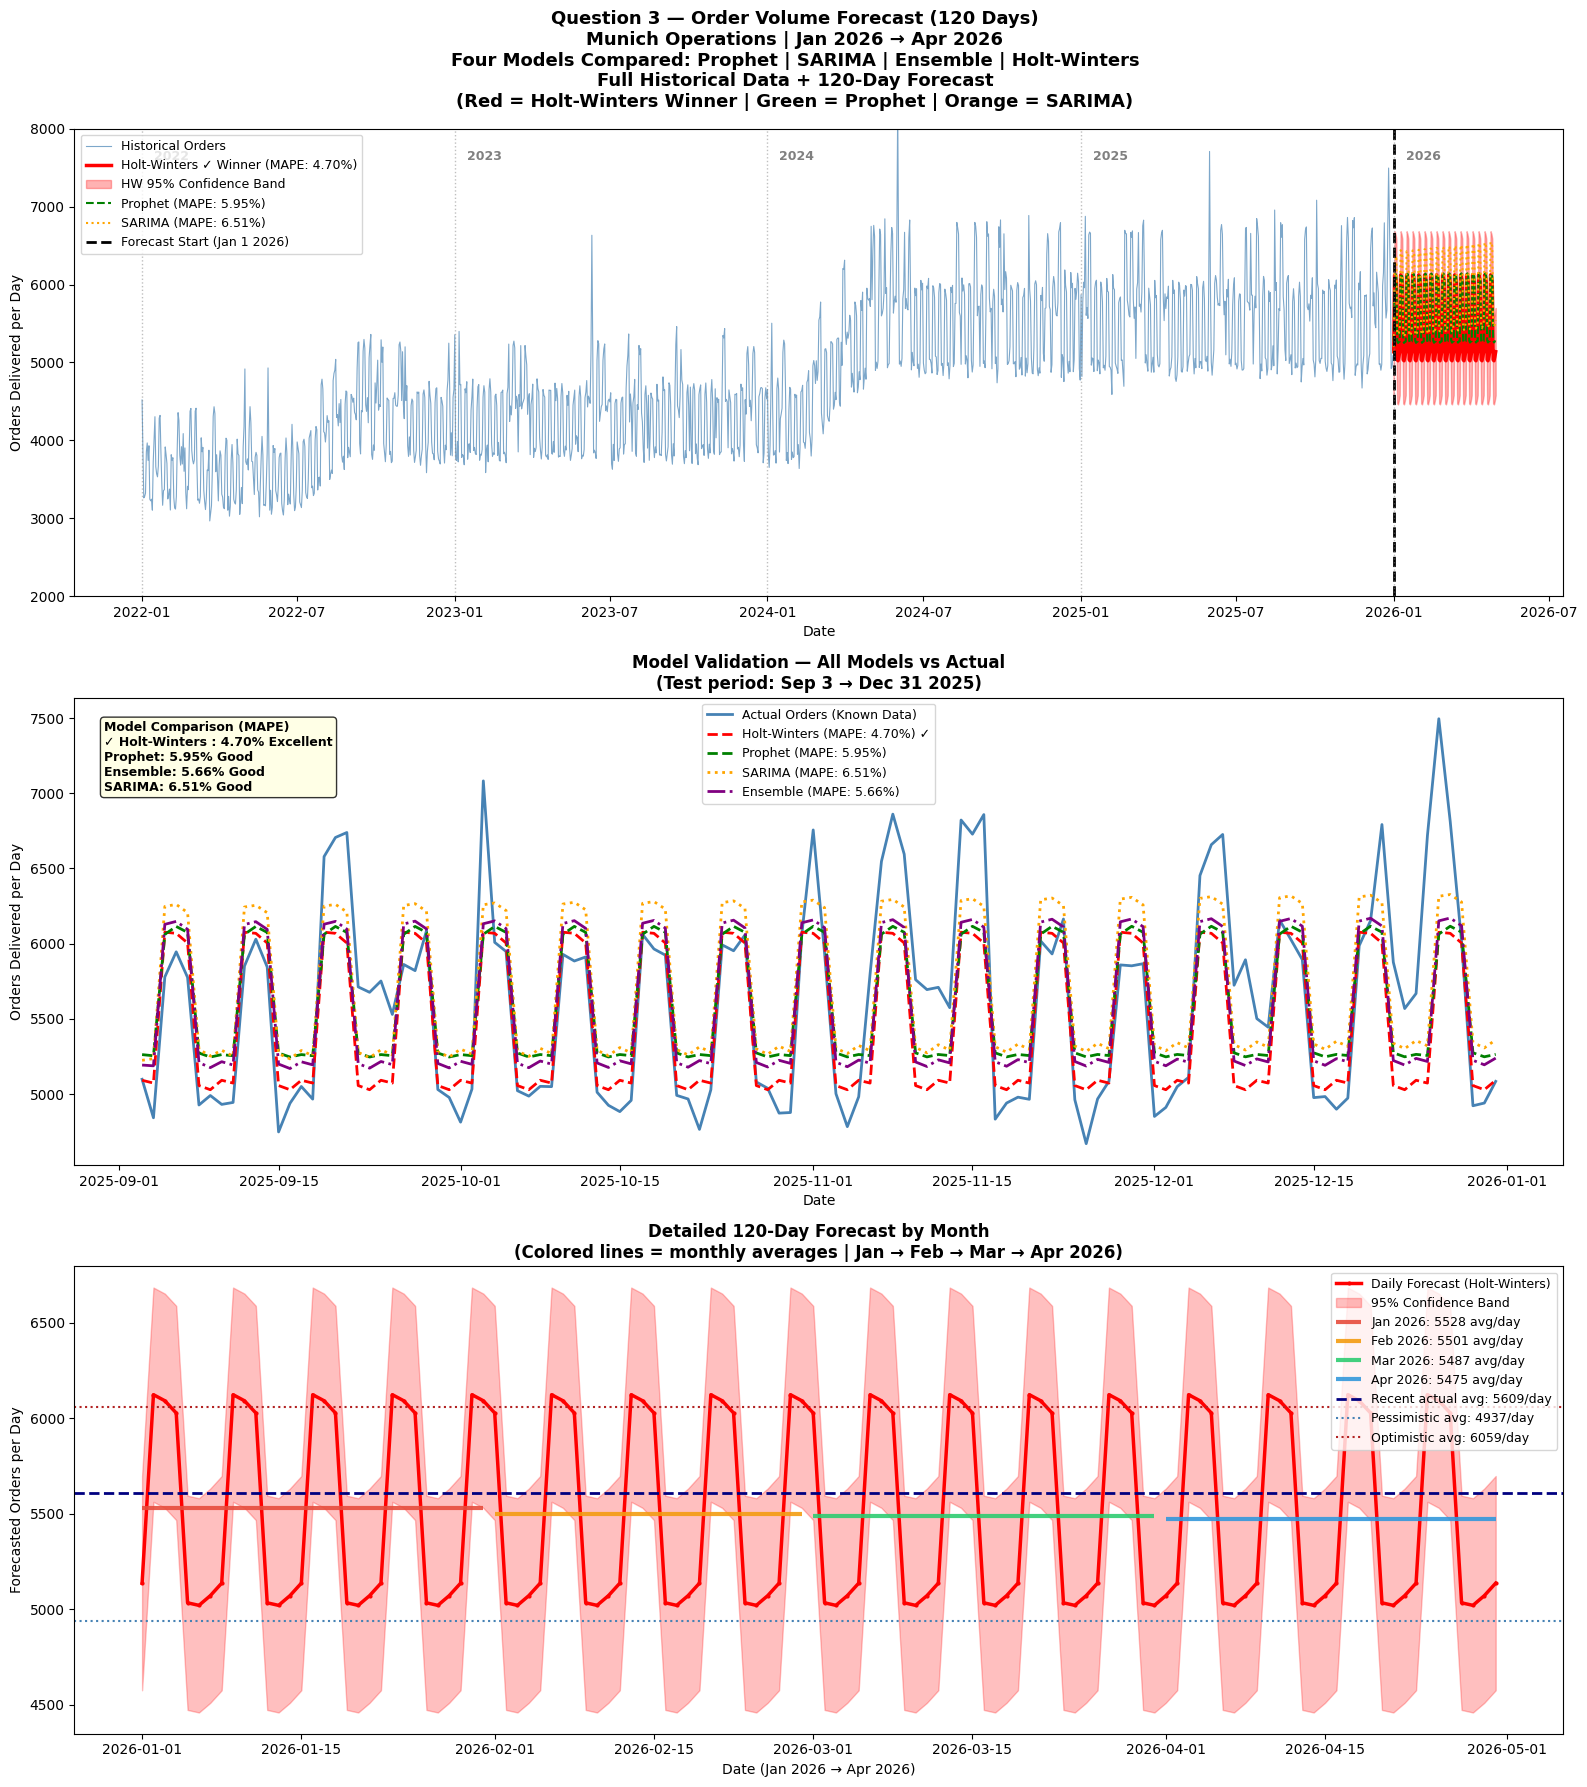

In [449]:
fig, axes = plt.subplots(3, 1, figsize=(16, 18))
fig.suptitle(
    'Question 3 — Order Volume Forecast (120 Days)\n'
    'Munich Operations | Jan 2026 → Apr 2026\n'
    'Four Models Compared: Prophet | SARIMA | Ensemble | Holt-Winters\n'
    'Full Historical Data + 120-Day Forecast\n'
    '(Red = Holt-Winters Winner | Green = Prophet | Orange = SARIMA)',
    fontsize=13, fontweight='bold', y=0.99)

# Plot 1 — full historical series with all three model forecasts appended
ax1 = axes[0]

ax1.plot(ts_df.index,
         ts_df['orders_delivered'],
         color='steelblue', linewidth=0.8,
         alpha=0.7, label='Historical Orders')

ax1.plot(forecast_index, forecast_values,
         color='red', linewidth=2.5,
         label=f'Holt-Winters ✓ Winner (MAPE: {hw_mape:.2f}%)')

ax1.fill_between(forecast_index,
                 forecast_lower, forecast_upper,
                 alpha=0.3, color='red',
                 label='HW 95% Confidence Band')

ax1.plot(forecast_index, prophet_fc_values,
         color='green', linewidth=1.5, linestyle='--',
         label=f'Prophet (MAPE: {prophet_mape:.2f}%)')

ax1.plot(forecast_index, sarima_fc_values,
         color='orange', linewidth=1.5, linestyle=':',
         label=f'SARIMA (MAPE: {sarima_mape:.2f}%)')

ax1.axvline(x=forecast_index[0],
            color='black', linestyle='--', linewidth=2,
            label='Forecast Start (Jan 1 2026)')

for year in [2022, 2023, 2024, 2025, 2026]:
    ax1.axvline(x=pd.Timestamp(f'{year}-01-01'),
                color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax1.text(pd.Timestamp(f'{year}-01-15'), 7600, str(year),
             fontsize=9, color='gray', fontweight='bold')

ax1.set_xlabel('Date')
ax1.set_ylabel('Orders Delivered per Day')
ax1.legend(loc='upper left', fontsize=9)
ax1.set_ylim(2000, 8000)

# Plot 2 — validation period: all four models vs actual on held-out test set
ax2 = axes[1]

ax2.plot(test.index, test.values,
         color='steelblue', linewidth=2,
         label='Actual Orders (Known Data)')
ax2.plot(test.index, hw_pred.values,
         color='red', linewidth=2, linestyle='--',
         label=f'Holt-Winters (MAPE: {hw_mape:.2f}%) \u2713')
ax2.plot(test.index, prophet_pred,
         color='green', linewidth=2, linestyle='--',
         label=f'Prophet (MAPE: {prophet_mape:.2f}%)')
ax2.plot(test.index, sarima_pred.values,
         color='orange', linewidth=2, linestyle=':',
         label=f'SARIMA (MAPE: {sarima_mape:.2f}%)')
ax2.plot(test.index, ensemble_pred,
         color='purple', linewidth=2, linestyle='-.',
         label=f'Ensemble (MAPE: {ensemble_mape:.2f}%)')

ax2.annotate(
    f'Model Comparison (MAPE)\n'
    f'\u2713 Holt-Winters : {hw_mape:.2f}% Excellent\n'
    f'Prophet: {prophet_mape:.2f}% Good\n'
    f'Ensemble: {ensemble_mape:.2f}% Good\n'
    f'SARIMA: {sarima_mape:.2f}% Good',
    xy=(0.02, 0.95), xycoords='axes fraction',
    fontsize=9, fontweight='bold',
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

ax2.set_title('Model Validation — All Models vs Actual\n'
              '(Test period: Sep 3 \u2192 Dec 31 2025)',
              fontweight='bold', fontsize=12)
ax2.set_xlabel('Date')
ax2.set_ylabel('Orders Delivered per Day')
ax2.legend(fontsize=9)

# Plot 3 — Jan-Apr 2026 daily forecast with monthly average lines
ax3 = axes[2]

ax3.plot(forecast_df['date'], forecast_df['forecast'],color='red', linewidth=2.5, marker='o', markersize=2,label='Daily Forecast (Holt-Winters)')

ax3.fill_between(forecast_df['date'],forecast_df['lower'], forecast_df['upper'],alpha=0.25, color='red',label='95% Confidence Band')

month_colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
monthly_avg  = forecast_df.groupby('month')['forecast'].mean()
month_starts = forecast_df.groupby('month')['date'].min()
month_ends   = forecast_df.groupby('month')['date'].max()

for month, color in zip(month_order, month_colors):
    avg   = monthly_avg[month]
    start = month_starts[month]
    end   = month_ends[month]
    ax3.hlines(y=avg, xmin=start, xmax=end,
               colors=color, linewidth=3, alpha=0.9,
               label=f'{month}: {avg:.0f} avg/day')

recent_actual_avg = float(ts_df['orders_delivered'].iloc[-120:].mean())
ax3.axhline(y=recent_actual_avg, color='navy',
            linestyle='--', linewidth=2,
            label=f'Recent actual avg: {recent_actual_avg:.0f}/day')

ax3.axhline(y=pessimistic, color='steelblue',
            linestyle=':', linewidth=1.5,
            label=f'Pessimistic avg: {pessimistic:.0f}/day')
ax3.axhline(y=optimistic, color='firebrick',
            linestyle=':', linewidth=1.5,
            label=f'Optimistic avg: {optimistic:.0f}/day')

ax3.set_title('Detailed 120-Day Forecast by Month\n'
              '(Colored lines = monthly averages | '
              'Jan \u2192 Feb \u2192 Mar \u2192 Apr 2026)',
              fontweight='bold', fontsize=12)
ax3.set_xlabel('Date (Jan 2026 \u2192 Apr 2026)')
ax3.set_ylabel('Forecasted Orders per Day')
ax3.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('q3_forecast_final.png', dpi=150, bbox_inches='tight')
plt.show()

# Question 4 — Required Drivers Estimation (90 Days)

In [450]:
# City efficiency stable at 2.147 across all 4 years — validated in Q2
EFFICIENCY = 2.147

# Opening hours calculated directly from the data
avg_opening_hours = df_clean['daily_opening_hours'].mean()
weekday_hours = df_clean[df_clean['is_weekend'] == 0]['daily_opening_hours'].mean()
weekend_hours = df_clean[df_clean['is_weekend'] == 1]['daily_opening_hours'].mean()

# 10% buffer covers forecast MAPE of 4.70% plus operational contingency
BUFFER = 1.10

print(f"City efficiency : {EFFICIENCY:.3f} orders/working hour")
print(f"Avg daily opening hours : {avg_opening_hours:.2f} hrs")
print(f"Weekday opening hours   : {weekday_hours:.2f} hrs")
print(f"Weekend opening hours   : {weekend_hours:.2f} hrs")
print(f"Planning buffer : +{BUFFER*100-100:.0f}% above base")

City efficiency : 2.147 orders/working hour
Avg daily opening hours : 12.36 hrs
Weekday opening hours   : 11.90 hrs
Weekend opening hours   : 13.50 hrs
Planning buffer : +10% above base


In [451]:
# take first 90 of the 120-day forecast
drivers_df = forecast_df.iloc[:90].copy()

drivers_df['is_weekend'] = drivers_df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)
drivers_df['opening_hours'] = drivers_df['is_weekend'].map({
    0: weekday_hours,
    1: weekend_hours
})

print(f"90-day window : {drivers_df['date'].iloc[0].date()} -> " f"{drivers_df['date'].iloc[-1].date()}")
print(f"Days included : {len(drivers_df)}")
print(f"Avg forecast  : {drivers_df['forecast'].mean():.0f} orders/day")

90-day window : 2026-01-01 -> 2026-03-31
Days included : 90
Avg forecast  : 5506 orders/day


In [452]:
# Base — uses central forecast directly
drivers_df['required_hours_base'] = (drivers_df['forecast'] / EFFICIENCY).round(1)
drivers_df['drivers_base'] = (drivers_df['required_hours_base'] / drivers_df['opening_hours']).round(0).astype(int)

# Pessimistic — uses lower confidence bound
drivers_df['required_hours_pess'] = (drivers_df['lower'] / EFFICIENCY).round(1)
drivers_df['drivers_pessimistic'] = (drivers_df['required_hours_pess'] / drivers_df['opening_hours']).round(0).astype(int)

# Optimistic — uses upper confidence bound
drivers_df['required_hours_opt'] = (
    drivers_df['upper'] / EFFICIENCY).round(1)
drivers_df['drivers_optimistic'] = (drivers_df['required_hours_opt'] / drivers_df['opening_hours']).round(0).astype(int)

# Buffered — base plus 10% for breaks, no-shows, demand spikes
drivers_df['drivers_buffered'] = (drivers_df['drivers_base'] * BUFFER).round(0).astype(int)

print(f"{'Scenario':<20} {'Avg':>8} {'Min':>8} {'Max':>8}")
print("-" * 46)
for scenario, col in [
    ('Pessimistic','drivers_pessimistic'),
    ('Base','drivers_base'),
    ('Buffered (+10%)','drivers_buffered'),
    ('Optimistic','drivers_optimistic')
]:
    print(f"{scenario:<20} "
          f"{drivers_df[col].mean():>8.0f} "
          f"{drivers_df[col].min():>8.0f} "
          f"{drivers_df[col].max():>8.0f}")

Scenario                  Avg      Min      Max
----------------------------------------------
Pessimistic               186      175      218
Base                      208      197      240
Buffered (+10%)           228      217      264
Optimistic                229      218      262


In [453]:
# Day-of-week breakdown — operations team needs per-day staffing targets
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

drivers_df.groupby('day_of_week').agg(
    avg_orders   = ('forecast','mean'),
    avg_hours    = ('required_hours_base','mean'),
    avg_drivers  = ('drivers_base','mean'),
    buff_drivers = ('drivers_buffered','mean')
).round(1).reindex(dow_order)

,avg_orders,avg_hours,avg_drivers,buff_drivers
day_of_week,,,,
Monday,5034.30,2344.80,197.00,217.00
Tuesday,5021.00,2338.60,197.00,217.00
Wednesday,5071.70,2362.20,199.00,219.00
Thursday,5137.20,2392.70,201.00,221.00
Friday,6123.50,2852.10,240.00,264.00
Saturday,6091.70,2837.30,210.00,231.00
Sunday,6027.80,2807.50,208.00,229.00


In [454]:
month_order_90 = ['Jan 2026', 'Feb 2026', 'Mar 2026']

drivers_df.groupby('month', observed=True).agg(
    days              = ('forecast','count'),
    avg_daily_orders  = ('forecast','mean'),
    avg_drivers_base  = ('drivers_base','mean'),
    avg_drivers_buff  = ('drivers_buffered','mean'),
    avg_drivers_pess  = ('drivers_pessimistic','mean'),
    avg_drivers_opt   = ('drivers_optimistic','mean'),
    total_hours_needed= ('required_hours_base','sum')
).round(1).reindex(month_order_90)

,days,avg_daily_orders,avg_drivers_base,avg_drivers_buff,avg_drivers_pess,avg_drivers_opt,total_hours_needed
month,,,,,,,
Jan 2026,31,5528.40,208.40,229.30,187.20,229.40,79822.90
Feb 2026,28,5501.00,207.40,228.30,186.30,228.40,71740.80
Mar 2026,31,5487.50,206.80,227.60,185.60,227.70,79231.70


In [455]:
# Validate estimates against historical — working_hours / opening_hours = implied drivers on road
df_clean['implied_drivers'] = (df_clean['working_hours'] / df_clean['daily_opening_hours']).round(0)

df_clean.groupby('year').agg(
    avg_implied_drivers = ('implied_drivers','mean'),
    avg_orders= ('orders_delivered','mean'),
    avg_efficiency = ('orders_per_working_hour','mean')
).round(1)

,avg_implied_drivers,avg_orders,avg_efficiency
year,,,
2022,148.00,3920.50,2.10
2023,163.00,4328.50,2.20
2024,201.10,5336.70,2.10
2025,212.30,5609.90,2.10


In [456]:
weekend_drivers = drivers_df[drivers_df['is_weekend'] == 1]['drivers_base'].mean()
weekday_drivers = drivers_df[drivers_df['is_weekend'] == 0]['drivers_base'].mean()
max_day = drivers_df.loc[drivers_df['drivers_base'].idxmax()]
min_day = drivers_df.loc[drivers_df['drivers_base'].idxmin()]

print(f"Weekday avg drivers : {weekday_drivers:.0f}")
print(f"Weekend avg drivers : {weekend_drivers:.0f}")
print(f"Weekend premium: +{weekend_drivers - weekday_drivers:.0f} drivers " f"({(weekend_drivers / weekday_drivers - 1)*100:.1f}% more)")

print(f"\nPeak day:")
print(f"{max_day['date'].date()}  {max_day['day_of_week']}"  f" {max_day['forecast']:.0f} orders  " f"{max_day['drivers_base']} drivers")

print(f"\nQuietest day:")
print(f"{min_day['date'].date()}  {min_day['day_of_week']}" f" {min_day['forecast']:.0f} orders  " f"{min_day['drivers_base']} drivers")

print(f"\nForecast base drivers (avg): {drivers_df['drivers_base'].mean():.0f}/day")
print(f"Forecast buffered drivers (avg) : {drivers_df['drivers_buffered'].mean():.0f}/day")
print(f"2025 historical implied drivers : " f"{df_clean[df_clean['year'] == 2025]['implied_drivers'].mean():.0f}/day")

Weekday avg drivers : 207
Weekend avg drivers : 209
Weekend premium: +2 drivers (1.0% more)

Peak day:
2026-01-02  Friday 6123 orders  240 drivers

Quietest day:
2026-01-05  Monday 5034 orders  197 drivers

Forecast base drivers (avg): 208/day
Forecast buffered drivers (avg) : 228/day
2025 historical implied drivers : 212/day


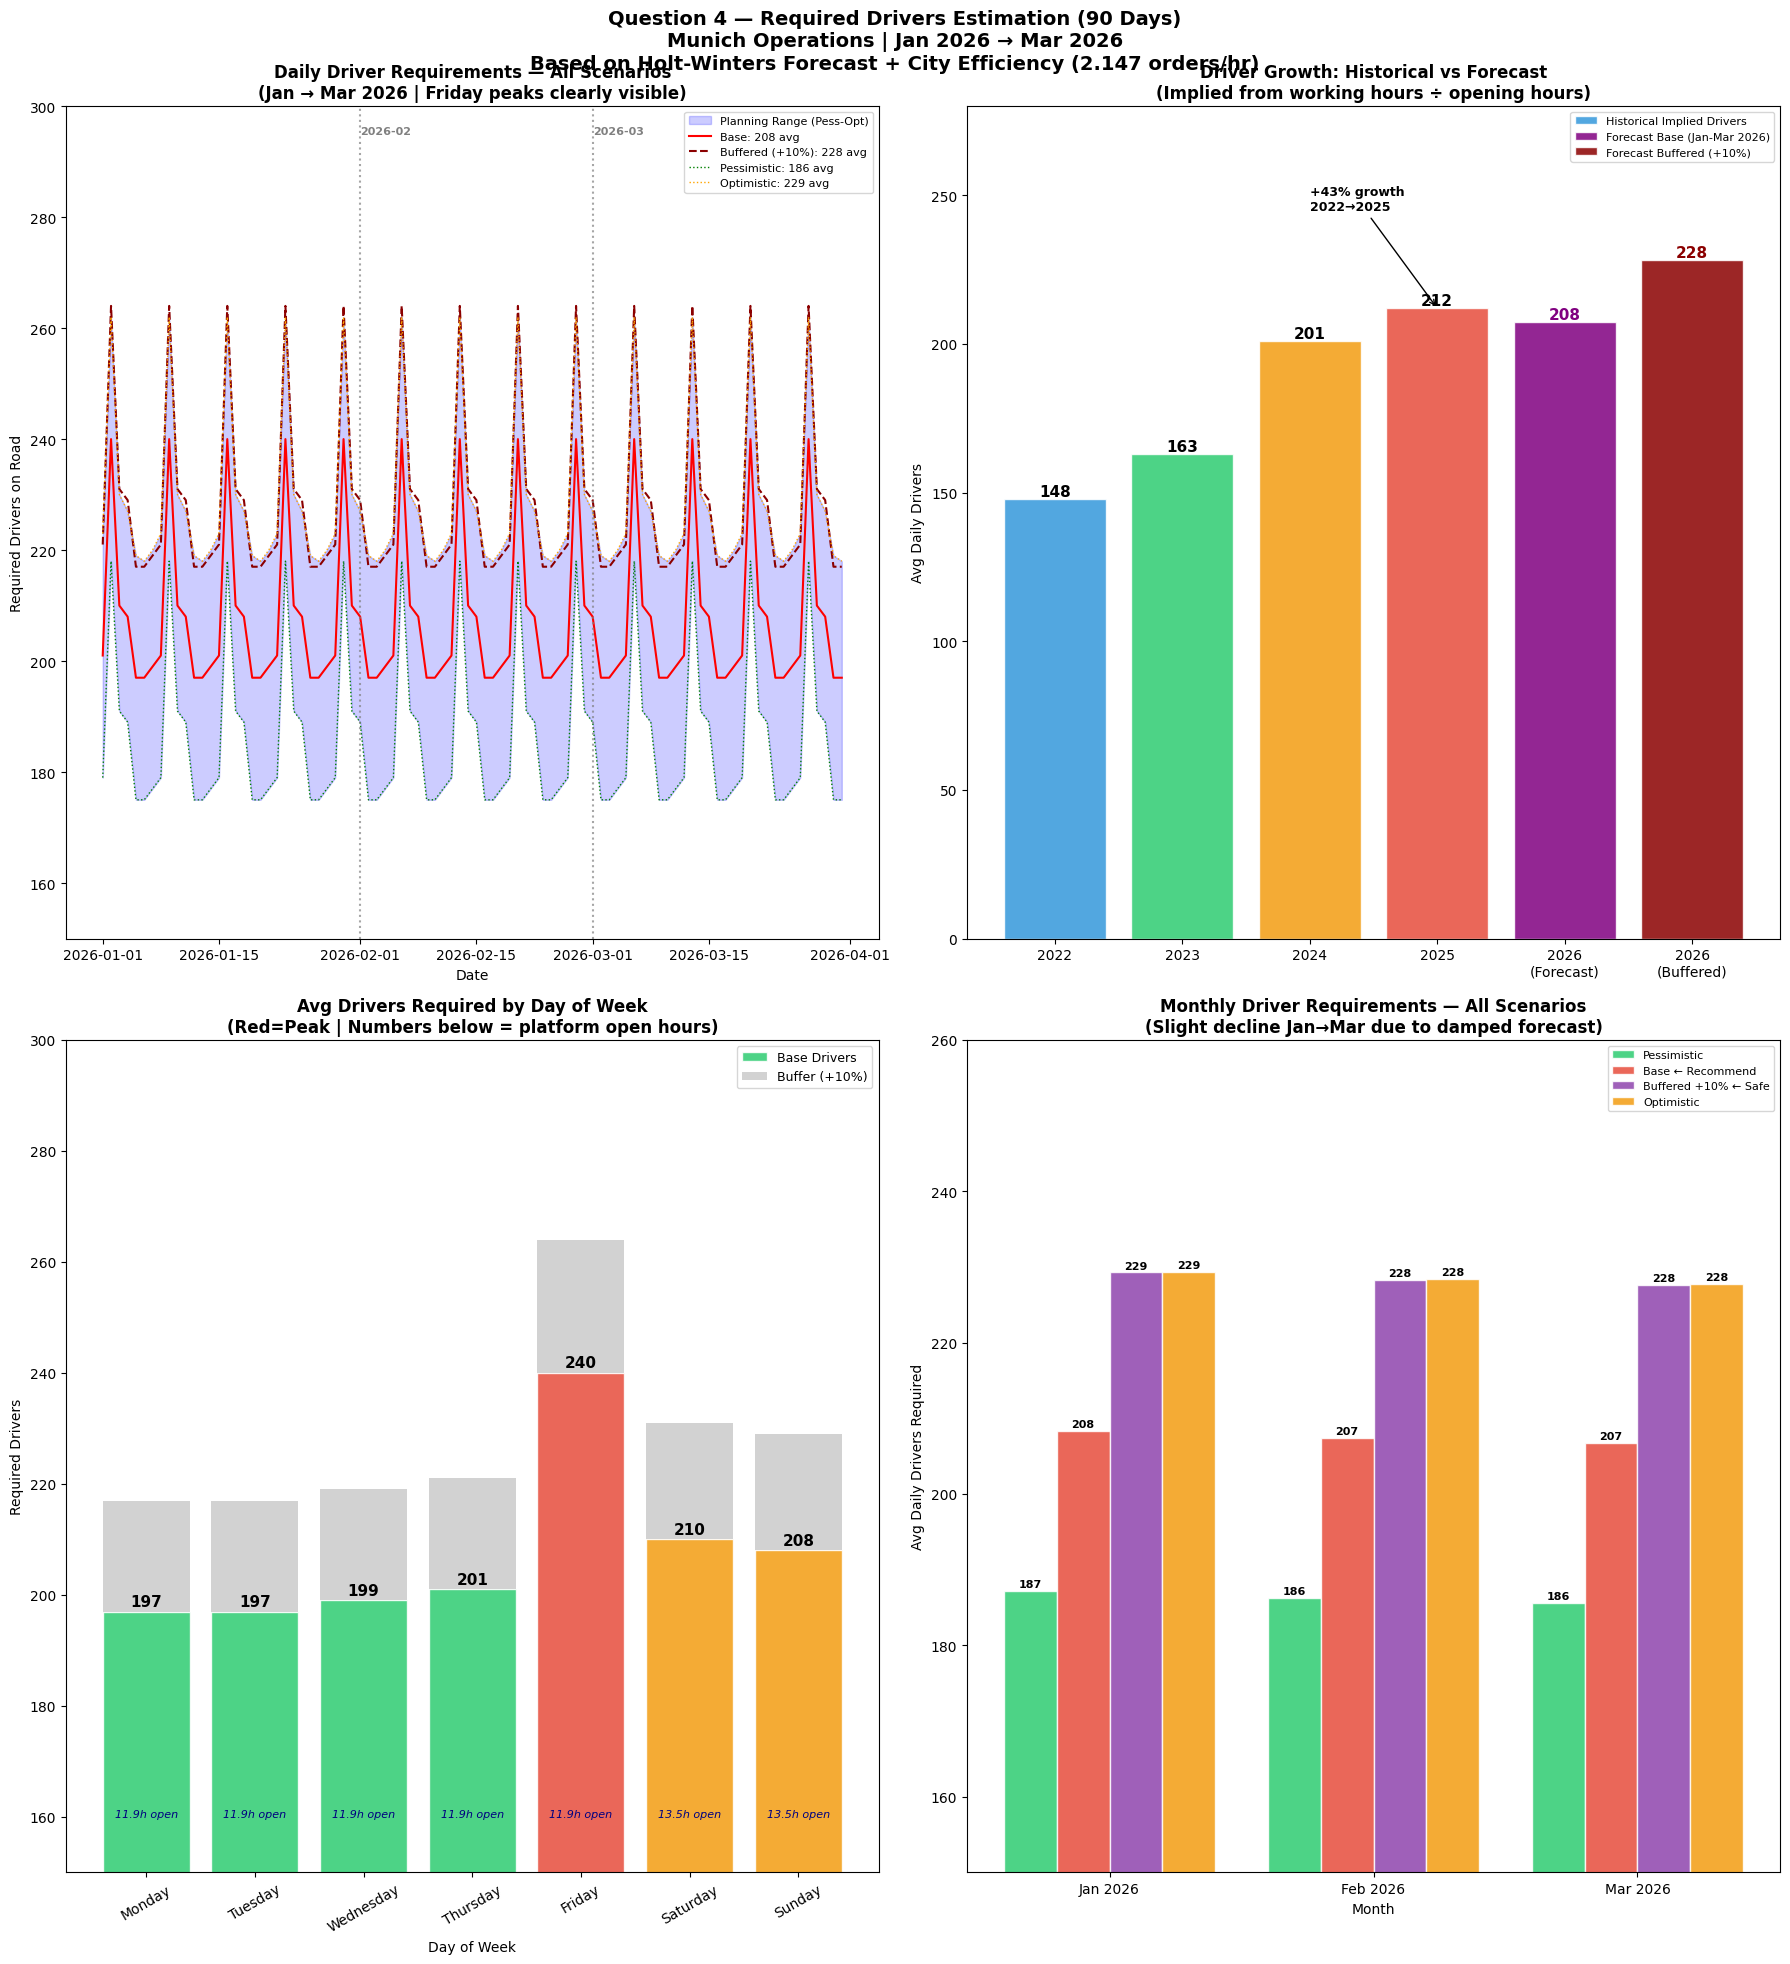

In [307]:
fig, axes = plt.subplots(2, 2, figsize=(18, 20))
fig.suptitle(
    'Question 4 — Required Drivers Estimation (90 Days)\n'
    'Munich Operations | Jan 2026 \u2192 Mar 2026\n'
    'Based on Holt-Winters Forecast + City Efficiency (2.147 orders/hr)',
    fontsize=14, fontweight='bold', y=0.98)

# Plot 1 — daily driver requirements across all scenarios

ax1 = axes[0, 0]

ax1.fill_between(
    drivers_df['date'],
    drivers_df['drivers_pessimistic'],
    drivers_df['drivers_optimistic'],
    alpha=0.2, color='blue',
    label=f'Planning Range (Pess-Opt)')

ax1.plot(drivers_df['date'], drivers_df['drivers_base'],color='red', linewidth=1.5,label=f'Base: {drivers_df["drivers_base"].mean():.0f} avg')
ax1.plot(drivers_df['date'], drivers_df['drivers_buffered'],color='darkred', linewidth=1.5, linestyle='--',label=f'Buffered (+10%): {drivers_df["drivers_buffered"].mean():.0f} avg')
ax1.plot(drivers_df['date'], drivers_df['drivers_pessimistic'],color='green', linewidth=1, linestyle=':',label=f'Pessimistic: {drivers_df["drivers_pessimistic"].mean():.0f} avg')
ax1.plot(drivers_df['date'], drivers_df['drivers_optimistic'],color='orange', linewidth=1, linestyle=':',label=f'Optimistic: {drivers_df["drivers_optimistic"].mean():.0f} avg')

for month_start in ['2026-02-01', '2026-03-01']:
    ax1.axvline(x=pd.Timestamp(month_start),
                color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
    ax1.text(pd.Timestamp(month_start), 295,
             month_start[:7], fontsize=8, color='gray', fontweight='bold')

ax1.set_title('Daily Driver Requirements — All Scenarios\n' '(Jan \u2192 Mar 2026 | Friday peaks clearly visible)',fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Required Drivers on Road')
ax1.legend(fontsize=8, loc='upper right')
ax1.set_ylim(150, 300)

# Plot 2 — historical implied drivers vs forecast
# historical = working_hours / opening_hours per year

ax2 = axes[0, 1]

hist_yearly = df_clean.groupby('year')['implied_drivers'].mean().round(0)
hist_years  = hist_yearly.index.astype(str).tolist()
hist_vals   = hist_yearly.values.tolist()
hist_colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

bars_hist = ax2.bar(hist_years, hist_vals,color=hist_colors, alpha=0.85, edgecolor='white',label='Historical Implied Drivers')

fc_base = drivers_df['drivers_base'].mean()
fc_buff = drivers_df['drivers_buffered'].mean()

bar_base = ax2.bar('2026\n(Forecast)', fc_base,color='purple', alpha=0.85, edgecolor='white',label='Forecast Base (Jan-Mar 2026)')
bar_buff = ax2.bar('2026\n(Buffered)', fc_buff,color='darkred', alpha=0.85, edgecolor='white',label='Forecast Buffered (+10%)')

for bar, val in zip(bars_hist, hist_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1, f'{val:.0f}',
             ha='center', fontweight='bold', fontsize=11)

for bar, val, col in [(bar_base[0], fc_base, 'purple'),
                      (bar_buff[0], fc_buff, 'darkred')]:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1, f'{val:.0f}',
             ha='center', fontweight='bold', fontsize=11, color=col)

growth_pct = (hist_vals[-1] - hist_vals[0]) / hist_vals[0] * 100
ax2.annotate(f'+{growth_pct:.0f}% growth\n2022\u21922025',xy=(3, hist_vals[-1]), xytext=(2, 245),arrowprops=dict(arrowstyle='->', color='black'),fontsize=9, fontweight='bold')

ax2.set_title('Driver Growth: Historical vs Forecast\n'
              '(Implied from working hours \u00f7 opening hours)',
              fontweight='bold')
ax2.set_ylabel('Avg Daily Drivers')
ax2.set_ylim(0, 280)
ax2.legend(fontsize=8)

# Plot 3 — average drivers required by day of week
ax3 = axes[1, 0]

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_base_vals = drivers_df.groupby('day_of_week')['drivers_base'].mean().reindex(dow_order)
dow_buff_vals = drivers_df.groupby('day_of_week')['drivers_buffered'].mean().reindex(dow_order)
dow_hrs       = drivers_df.groupby('day_of_week')['opening_hours'].mean().reindex(dow_order)

colors_dow = ['#e74c3c' if v == dow_base_vals.max()
              else '#f39c12' if v >= 205
              else '#2ecc71'
              for v in dow_base_vals.values]

bars3 = ax3.bar(dow_order, dow_base_vals.values,color=colors_dow, alpha=0.85, edgecolor='white',label='Base Drivers')
ax3.bar(dow_order,dow_buff_vals.values - dow_base_vals.values,bottom=dow_base_vals.values,color='gray', alpha=0.35, label='Buffer (+10%)')

for bar, val in zip(bars3, dow_base_vals.values):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1, f'{val:.0f}',
             ha='center', fontweight='bold', fontsize=11)

for i, hrs in enumerate(dow_hrs.values):
    ax3.text(i, 160, f'{hrs:.1f}h open',
             ha='center', fontsize=8, color='navy', style='italic')

ax3.set_title('Avg Drivers Required by Day of Week\n'
              '(Red=Peak | Numbers below = platform open hours)',
              fontweight='bold')
ax3.set_xlabel('Day of Week')
ax3.set_ylabel('Required Drivers')
ax3.legend(fontsize=9)
ax3.tick_params(axis='x', rotation=30)
ax3.set_ylim(150, 300)

# Plot 4 — monthly driver requirements across all scenarios

ax4 = axes[1, 1]

month_order_90 = ['Jan 2026', 'Feb 2026', 'Mar 2026']
monthly_plot   = drivers_df.groupby('month', observed=True).agg(
    pess = ('drivers_pessimistic', 'mean'),
    base = ('drivers_base',        'mean'),
    buff = ('drivers_buffered',    'mean'),
    opt  = ('drivers_optimistic',  'mean')
).reindex(month_order_90)

x = np.arange(len(month_order_90))
width = 0.2

bars_p = ax4.bar(x - width*1.5, monthly_plot['pess'], width,label='Pessimistic',color='#2ecc71', alpha=0.85, edgecolor='white')
bars_b = ax4.bar(x - width*0.5, monthly_plot['base'], width,label='Base \u2190 Recommend',color='#e74c3c', alpha=0.85, edgecolor='white')
bars_f = ax4.bar(x + width*0.5, monthly_plot['buff'], width,label='Buffered +10% \u2190 Safe', color='#8e44ad', alpha=0.85, edgecolor='white')
bars_o = ax4.bar(x + width*1.5, monthly_plot['opt'],  width,label='Optimistic',color='#f39c12', alpha=0.85, edgecolor='white')

for bars_grp in [bars_p, bars_b, bars_f, bars_o]:
    for bar in bars_grp:
        ax4.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{bar.get_height():.0f}',
                 ha='center', fontsize=8, fontweight='bold')

ax4.set_title('Monthly Driver Requirements — All Scenarios\n''(Slight decline Jan\u2192Mar due to damped forecast)',fontweight='bold')
ax4.set_xlabel('Month')
ax4.set_ylabel('Avg Daily Drivers Required')
ax4.set_xticks(x)
ax4.set_xticklabels(month_order_90)
ax4.legend(fontsize=8)
ax4.set_ylim(150, 260)


plt.tight_layout()
plt.savefig('q4_driver_estimation_v5.png', dpi=150, bbox_inches='tight')
plt.show()

# Additional Analysis — Lost Revenue Quantification

In [457]:
# AOV from Just Eat Takeaway reported figure
# Source: businessofapps.com/data/just-eat-statistics
# Commission rate implied from 2023 financials: Revenue €3.1B ÷ GMV €17.0B = 18.2%
AOV = 26.00
COMMISSION = 0.18

print(f"Average Order Value : €{AOV:.2f}  "
      f"(JET reported — businessofapps.com)")
print(f"Platform Commission : {COMMISSION*100:.0f}%  "
      f"(implied from revenue ÷ GMV)")
print(f"Revenue per order   : €{AOV*COMMISSION:.2f}")

Average Order Value : €26.00  (JET reported — businessofapps.com)
Platform Commission : 18%  (implied from revenue ÷ GMV)
Revenue per order   : €4.68


In [458]:
yearly_revenue = df_clean.groupby('year').agg(
    orders_delivered = ('orders_delivered', 'sum'),
    potential        = ('potential','sum'),
    lost_orders      = ('lost_orders','sum'),
    fulfillment_rate = ('fulfillment_rate', 'mean')
).round(0)

yearly_revenue['lost_commission'] = (
    yearly_revenue['lost_orders'] * AOV * COMMISSION
).round(0)
yearly_revenue['delivered_commission'] = (
    yearly_revenue['orders_delivered'] * AOV * COMMISSION
).round(0)
yearly_revenue['lost_gross_rev'] = (
    yearly_revenue['lost_orders'] * AOV
).round(0)

print(f"{'Year':<6} {'Delivered':>12} {'Lost Orders':>12} " f"{'Lost Commission (€)':>22}")
print("-" * 55)

for year, row in yearly_revenue.iterrows():
    print(f"{year:<6} {row['orders_delivered']:>12,.0f} "
          f"{row['lost_orders']:>12,.0f} "
          f"{row['lost_commission']:>22,.0f}")

total_lost_commission = yearly_revenue['lost_commission'].sum()
total_lost_revenue    = yearly_revenue['lost_gross_rev'].sum()

print("-" * 55)
print(f"{'TOTAL':<6} "
      f"{yearly_revenue['orders_delivered'].sum():>12,.0f} "
      f"{yearly_revenue['lost_orders'].sum():>12,.0f} "
      f"{total_lost_commission:>22,.0f}")

print(f"\n4-year total lost commission : €{total_lost_commission:,.0f}")
print(f"4-year total lost revenue: €{total_lost_revenue:,.0f}")
print(f"Avg lost commission per day: " f"€{total_lost_commission/len(df_clean):,.0f}")

Year      Delivered  Lost Orders    Lost Commission (€)
-------------------------------------------------------
2022      1,427,065      250,796              1,173,725
2023      1,579,893      279,051              1,305,959
2024      1,947,896      339,147              1,587,208
2025      2,041,997      354,660              1,659,809
-------------------------------------------------------
TOTAL     6,996,851    1,223,654              5,726,701

4-year total lost commission : €5,726,701
4-year total lost revenue: €31,815,004
Avg lost commission per day: €3,928


In [459]:
# How much additional annual commission does each 1% fulfillment gain unlock?
avg_daily_potential_2025 = df_clean[df_clean['year'] == 2025]['potential'].mean()
annual_potential_2025    = avg_daily_potential_2025 * 365

print(f"2025 annual potential demand : {annual_potential_2025:,.0f} orders\n")

print(f"{'Target':>10} {'Extra Orders/Yr':>17} "
      f"{'Extra Commission (€)':>22}")
print("-" * 52)

for target in [0.86, 0.87, 0.88, 0.89, 0.90]:
    extra_orders     = annual_potential_2025 * (target - 0.85)
    extra_commission = extra_orders * AOV * COMMISSION
    print(f"{target*100:>9.0f}%  "
          f"{extra_orders:>17,.0f}  "
          f"{extra_commission:>22,.0f}")

per_pct = annual_potential_2025 * 0.01 * AOV * COMMISSION
print(f"\nEach 1% fulfillment improvement : "
      f"€{per_pct:,.0f} additional annual commission")

2025 annual potential demand : 2,403,241 orders

    Target   Extra Orders/Yr   Extra Commission (€)
----------------------------------------------------
       86%             24,032                 112,472
       87%             48,065                 224,943
       88%             72,097                 337,415
       89%             96,130                 449,887
       90%            120,162                 562,358

Each 1% fulfillment improvement : €112,472 additional annual commission


In [460]:
# Initial Hypothesis Result:

print("H1 — Weekends worse for SLA : DISPROVED — weekend correlation = 0.04, negligible difference")
print("H2 — Assign time more volatile : DISPROVED — handling gap 2.19 mins vs assign gap 0.62 mins")
print("H3 — Fulfillment improving : DISPROVED — stuck at ~85% across all 4 years, R²=0.0008")
print("H4 — Efficiency seasonal : DISPROVED — monthly efficiency flat at 2.147 ± 0.02")
print("H5 — Speed drives rating : CONFIRMED — SLA met 3.621 vs missed 3.421, gap 0.200 stars")

H1 — Weekends worse for SLA : DISPROVED — weekend correlation = 0.04, negligible difference
H2 — Assign time more volatile : DISPROVED — handling gap 2.19 mins vs assign gap 0.62 mins
H3 — Fulfillment improving : DISPROVED — stuck at ~85% across all 4 years, R²=0.0008
H4 — Efficiency seasonal : DISPROVED — monthly efficiency flat at 2.147 ± 0.02
H5 — Speed drives rating : CONFIRMED — SLA met 3.621 vs missed 3.421, gap 0.200 stars


## Additional Analysis — SLA Improvement Simulation

In [461]:
current_compliance = df_clean['sla_met_25'].mean() * 100
current_avg_time   = df_clean['total_time_mins'].mean()
current_met_days   = int(df_clean['sla_met_25'].sum())
total_days         = len(df_clean)

print(f"Current avg delivery time : {current_avg_time:.2f} mins")
print(f"Current 25-min compliance : {current_compliance:.1f}%")
print(f"Days meeting target       : {current_met_days} of {total_days}")
print(f"Days missing target       : {total_days - current_met_days}")

Current avg delivery time : 24.71 mins
Current 25-min compliance : 57.5%
Days meeting target       : 838 of 1458
Days missing target       : 620


In [462]:
# Test multiple combinations of handling and assign time reductions
scenarios = {
    'Handling time -1 min': (1.0, 0.0),
    'Handling time -2 mins': (2.0, 0.0),
    'Handling time -3 mins': (3.0, 0.0),
    'Assign time -0.5 min': (0.0, 0.5),
    'Both: -1 handling -0.3 assign': (1.0, 0.3),
    'Both: -2 handling -0.5 assign': (2.0, 0.5),
}

print(f"{'Scenario':<35} {'Avg Time':>10} "
      f"{'Compliance':>12} {'Days Met':>10} {'Extra Days':>12}")
print("-" * 82)
print(f"{'Baseline (no change)':<35} "
      f"{current_avg_time:>9.2f}m "
      f"{current_compliance:>11.1f}% "
      f"{current_met_days:>10} "
      f"{'—':>12}")

results = []
for scenario, (h_reduction, a_reduction) in scenarios.items():
    sim_time = df_clean['total_time_mins'] - h_reduction - a_reduction
    sim_met  = int((sim_time <= 25).sum())
    sim_comp = sim_met / total_days * 100
    sim_avg  = sim_time.mean()
    extra    = sim_met - current_met_days

    print(f"{scenario:<35} "
          f"{sim_avg:>9.2f}m "
          f"{sim_comp:>11.1f}% "
          f"{sim_met:>10} "
          f"{extra:>+12}")

    results.append({
        'scenario': scenario,
        'h_reduction': h_reduction,
        'a_reduction': a_reduction,
        'simulated_avg': sim_avg,
        'simulated_comp': sim_comp,
        'simulated_met': sim_met,
        'extra_days': extra
    })

results_df = pd.DataFrame(results)

Scenario                              Avg Time   Compliance   Days Met   Extra Days
----------------------------------------------------------------------------------
Baseline (no change)                    24.71m        57.5%        838            —
Handling time -1 min                    23.71m        77.2%       1125         +287
Handling time -2 mins                   22.71m        90.7%       1322         +484
Handling time -3 mins                   21.71m        97.6%       1423         +585
Assign time -0.5 min                    24.21m        67.4%        982         +144
Both: -1 handling -0.3 assign           23.41m        82.4%       1201         +363
Both: -2 handling -0.5 assign           22.21m        95.7%       1395         +557


In [463]:
# Break down how a 2-min handling reduction affects each year separately
# useful to see whether the impact is consistent or driven by one specific year
print(f"{'Year':<6} {'Current %':>12} {'Simulated %':>14} {'Extra Days':>12}")
print("-" * 48)

for year in [2022, 2023, 2024, 2025]:
    yr_data  = df_clean[df_clean['year'] == year]
    curr_comp = yr_data['sla_met_25'].mean() * 100
    sim_time  = yr_data['total_time_mins'] - 2.0
    sim_comp  = (sim_time <= 25).mean() * 100
    extra     = len(yr_data) * (sim_comp - curr_comp) / 100
    print(f"{year:<6} {curr_comp:>11.1f}% "
          f"{sim_comp:>13.1f}% "
          f"{extra:>+12.0f}")

Year      Current %    Simulated %   Extra Days
------------------------------------------------
2022          68.4%          96.7%         +103
2023          63.0%          95.6%         +119
2024          51.8%          86.8%         +128
2025          46.7%          83.5%         +134


In [464]:
# Check if days with SLA met have meaningfully different ratings than missed days
# if yes — SLA improvement connects to retention and downstream revenue
met_rating= df_clean[df_clean['sla_met_25'] == 1]['delivery_rating'].mean()
missed_rating = df_clean[df_clean['sla_met_25'] == 0]['delivery_rating'].mean()
rating_gap= met_rating - missed_rating

print(f"Avg rating when SLA met: {met_rating:.3f}")
print(f"Avg rating when SLA missed : {missed_rating:.3f}")
print(f"Rating gap: {rating_gap:.3f} stars")


Avg rating when SLA met: 3.621
Avg rating when SLA missed : 3.421
Rating gap: 0.200 stars


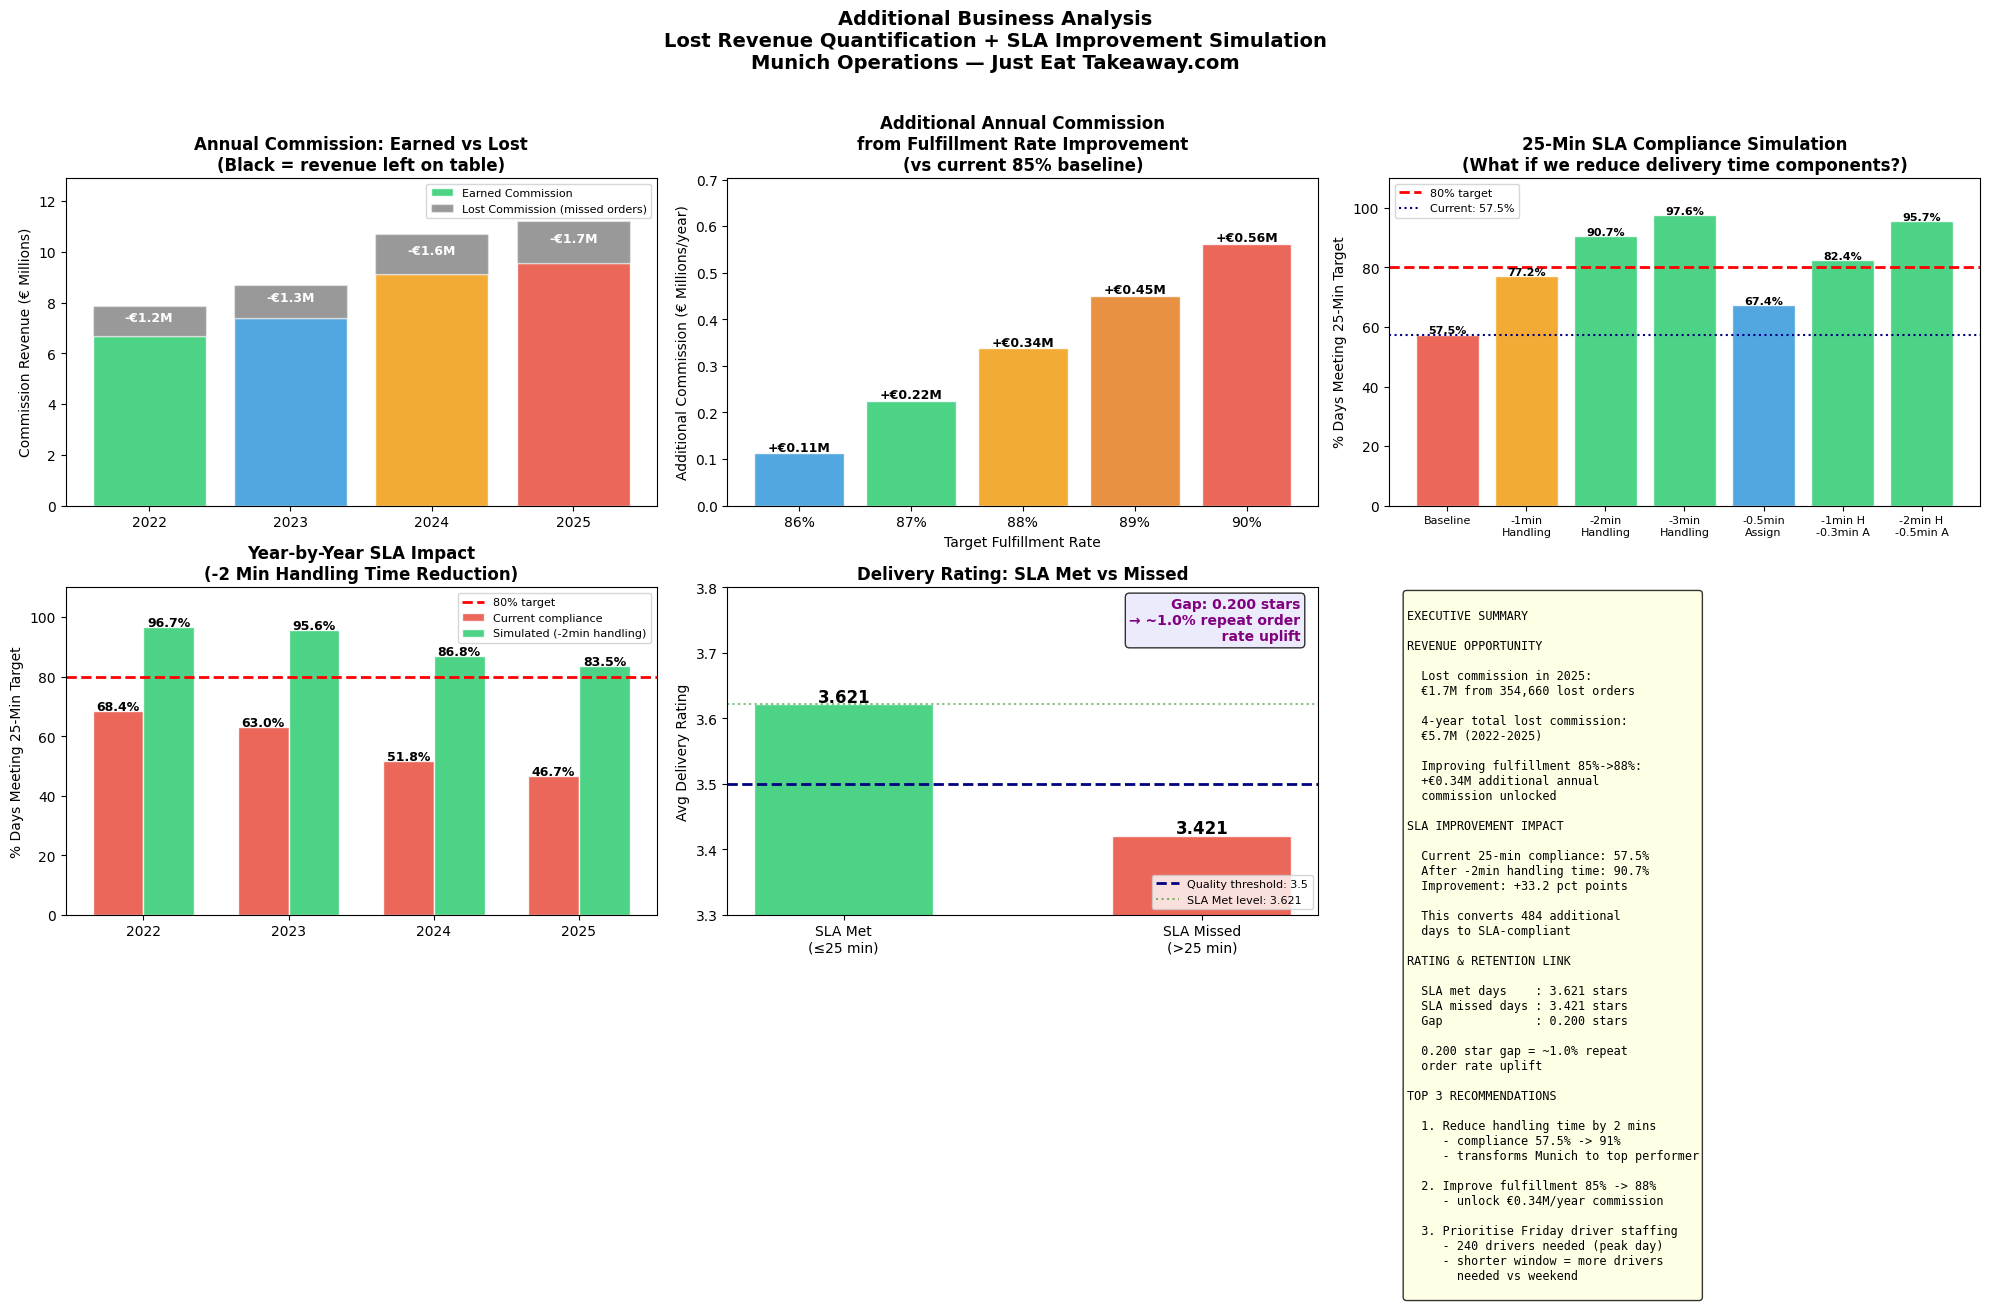

In [465]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(
    'Additional Business Analysis\n'
    'Lost Revenue Quantification + SLA Improvement Simulation\n'
    'Munich Operations — Just Eat Takeaway.com',
    fontsize=14, fontweight='bold', y=1.01)

# Plot 1 — stack earned and lost commission per year
ax1 = axes[0, 0]

years = yearly_revenue.index.tolist()
lost_comm = (yearly_revenue['lost_commission'] / 1e6).tolist()
delivered_comm = (yearly_revenue['delivered_commission'] / 1e6).tolist()

bars_d = ax1.bar([str(y) for y in years], delivered_comm,
                 color=['#2ecc71','#3498db','#f39c12','#e74c3c'],
                 alpha=0.85, edgecolor='white',
                 label='Earned Commission')

bars_l = ax1.bar([str(y) for y in years], lost_comm,
                 bottom=delivered_comm,
                 color='black', alpha=0.4, edgecolor='white',
                 label='Lost Commission (missed orders)')

for bar, val in zip(bars_l, lost_comm):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_y() + bar.get_height()/2,
             f'-\u20ac{val:.1f}M',
             ha='center', fontsize=9,
             fontweight='bold', color='white')

ax1.set_title('Annual Commission: Earned vs Lost\n''(Black = revenue left on table)',fontweight='bold')
ax1.set_ylabel('Commission Revenue (\u20ac Millions)')
ax1.legend(fontsize=8)
ax1.set_ylim(0, max([d+l for d, l in zip(delivered_comm, lost_comm)]) * 1.15)

# Plot 2 — revenue unlocked per percentage point of fulfillment improvement
ax2 = axes[0, 1]

fulfillment_targets    = [86, 87, 88, 89, 90]
additional_commissions = [
    annual_potential_2025 * (t/100 - 0.85) * AOV * COMMISSION / 1e6
    for t in fulfillment_targets
]

bars2 = ax2.bar([f'{t}%' for t in fulfillment_targets],
                additional_commissions,
                color=['#3498db','#2ecc71','#f39c12','#e67e22','#e74c3c'],
                alpha=0.85, edgecolor='white')

for bar, val in zip(bars2, additional_commissions):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'+\u20ac{val:.2f}M',
             ha='center', fontsize=9, fontweight='bold')

ax2.set_title('Additional Annual Commission\n'
              'from Fulfillment Rate Improvement\n'
              '(vs current 85% baseline)',
              fontweight='bold')
ax2.set_xlabel('Target Fulfillment Rate')
ax2.set_ylabel('Additional Commission (\u20ac Millions/year)')
ax2.set_ylim(0, max(additional_commissions) * 1.25)

# Plot 3 — compare compliance across handling and assign time reduction scenarios
ax3 = axes[0, 2]

scenario_labels = ['Baseline',
                   '-1min\nHandling', '-2min\nHandling', '-3min\nHandling',
                   '-0.5min\nAssign',
                   '-1min H\n-0.3min A', '-2min H\n-0.5min A']

compliance_vals = [current_compliance] + results_df['simulated_comp'].tolist()

colors_sim = ['#e74c3c'] + [
    '#2ecc71' if v >= 80 else '#f39c12' if v >= 70 else '#3498db'
    for v in results_df['simulated_comp']
]

bars3 = ax3.bar(scenario_labels, compliance_vals, color=colors_sim, alpha=0.85, edgecolor='white')

ax3.axhline(y=80, color='red', linestyle='--', linewidth=2, label='80% target')
ax3.axhline(y=current_compliance, color='navy', linestyle=':', linewidth=1.5, label=f'Current: {current_compliance:.1f}%')

for bar, val in zip(bars3, compliance_vals):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3, f'{val:.1f}%',
             ha='center', fontsize=8, fontweight='bold')

ax3.set_title('25-Min SLA Compliance Simulation\n'
              '(What if we reduce delivery time components?)',
              fontweight='bold')
ax3.set_ylabel('% Days Meeting 25-Min Target')
ax3.set_ylim(0, 110)
ax3.legend(fontsize=8)
ax3.tick_params(axis='x', labelsize=8)

# Plot 4 — year by year breakdown for the 2-min handling reduction scenario
# checks whether the improvement is consistent across years or concentrated in one period
ax4 = axes[1, 0]

yr_labels  = ['2022', '2023', '2024', '2025']
curr_comps = [
    df_clean[df_clean['year'] == y]['sla_met_25'].mean() * 100
    for y in [2022, 2023, 2024, 2025]
]
sim_comps_2 = [
    ((df_clean[df_clean['year'] == y]['total_time_mins'] - 2.0) <= 25).mean() * 100
    for y in [2022, 2023, 2024, 2025]
]

x= np.arange(len(yr_labels))
width = 0.35

bars4a = ax4.bar(x - width/2, curr_comps, width,
                 label='Current compliance',
                 color='#e74c3c', alpha=0.85, edgecolor='white')
bars4b = ax4.bar(x + width/2, sim_comps_2, width,
                 label='Simulated (-2min handling)',
                 color='#2ecc71', alpha=0.85, edgecolor='white')

for bar, val in zip(bars4a, curr_comps):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3, f'{val:.1f}%',
             ha='center', fontsize=9, fontweight='bold')

for bar, val in zip(bars4b, sim_comps_2):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3, f'{val:.1f}%',
             ha='center', fontsize=9, fontweight='bold')

ax4.axhline(y=80, color='red', linestyle='--', linewidth=2, label='80% target')
ax4.set_title('Year-by-Year SLA Impact\n' '(-2 Min Handling Time Reduction)',fontweight='bold')
ax4.set_ylabel('% Days Meeting 25-Min Target')
ax4.set_xticks(x)
ax4.set_xticklabels(yr_labels)
ax4.set_ylim(0, 110)
ax4.legend(fontsize=8)

# Plot 5 — compare average delivery rating on SLA met vs missed days
# checks whether SLA performance and customer rating move together
ax5 = axes[1, 1]

categories = ['SLA Met\n(\u226425 min)', 'SLA Missed\n(>25 min)']
ratings    = [met_rating, missed_rating]
colors_r   = ['#2ecc71', '#e74c3c']

bars5 = ax5.bar(categories, ratings,color=colors_r, alpha=0.85, edgecolor='white', width=0.5)

for bar, val in zip(bars5, ratings):
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003,
             f'{val:.3f}',
             ha='center', fontsize=12, fontweight='bold')

ax5.axhline(y=3.5, color='navy', linestyle='--', linewidth=2, label='Quality threshold: 3.5')
ax5.axhline(y=met_rating, color='green', linestyle=':', linewidth=1.5, alpha=0.5, label=f'SLA Met level: {met_rating:.3f}')

ax5.text(0.97, 0.97,
         f'Gap: {met_rating - missed_rating:.3f} stars\n'
         f'\u2192 ~1.0% repeat order\n'
         f'   rate uplift',
         transform=ax5.transAxes,
         fontsize=10, fontweight='bold',
         verticalalignment='top',
         horizontalalignment='right',
         color='purple',
         bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.8))

ax5.set_title('Delivery Rating: SLA Met vs Missed', fontweight='bold')
ax5.set_ylabel('Avg Delivery Rating')
ax5.set_ylim(3.3, 3.80)
ax5.legend(fontsize=8, loc='lower right')

# Plot 6 — executive summary pulling key numbers from all sections
ax6 = axes[1, 2]
ax6.axis('off')

lost_comm_2025  = yearly_revenue.loc[2025, 'lost_commission']
uplift_88       = annual_potential_2025 * 0.03 * AOV * COMMISSION
sim_comp_2min   = results_df[results_df['h_reduction'] == 2.0]['simulated_comp'].values[0]
extra_days_2min = results_df[results_df['h_reduction'] == 2.0]['extra_days'].values[0]

summary_text = f"""
EXECUTIVE SUMMARY

REVENUE OPPORTUNITY

  Lost commission in 2025:
  \u20ac{lost_comm_2025/1e6:.1f}M from {354660:,} lost orders

  4-year total lost commission:
  \u20ac{total_lost_commission/1e6:.1f}M (2022-2025)

  Improving fulfillment 85%->88%:
  +\u20ac{uplift_88/1e6:.2f}M additional annual
  commission unlocked

SLA IMPROVEMENT IMPACT

  Current 25-min compliance: {current_compliance:.1f}%
  After -2min handling time: {sim_comp_2min:.1f}%
  Improvement: +{sim_comp_2min - current_compliance:.1f} pct points

  This converts {extra_days_2min:,} additional
  days to SLA-compliant

RATING & RETENTION LINK

  SLA met days    : {met_rating:.3f} stars
  SLA missed days : {missed_rating:.3f} stars
  Gap             : {met_rating - missed_rating:.3f} stars

  0.200 star gap = ~1.0% repeat
  order rate uplift

TOP 3 RECOMMENDATIONS

  1. Reduce handling time by 2 mins
     - compliance {current_compliance:.1f}% -> {sim_comp_2min:.0f}%
     - transforms Munich to top performer

  2. Improve fulfillment 85% -> 88%
     - unlock \u20ac{uplift_88/1e6:.2f}M/year commission

  3. Prioritise Friday driver staffing
     - 240 drivers needed (peak day)
     - shorter window = more drivers
       needed vs weekend
"""

ax6.text(0.03, 0.98, summary_text,
         transform=ax6.transAxes,
         fontsize=8.5, verticalalignment='top',
         fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('additional_analysis_v4.png', dpi=150, bbox_inches='tight')
plt.show()